# Model Comparison — All Clustering Methods

> **ENSIA · OULAD Student Clustering · Spring 2025–2026**

Loads saved artifacts from notebooks 03–06 and 09; compares internal metrics, external validation, bootstrap stability, and at-risk detection.

| Notebook | Method | Assignment |
|---|---|---|
| 03 | K-Means (Euclidean + Manhattan) | Hard |
| 04 | Hierarchical (Ward) | Hard |
| 05 | DBSCAN | Hard + noise |
| 06 | GMM (full covariance) | Soft |
| 09 | DTW + Louvain (fine + merged) | Hard (graph) |

**Notebook files:** Keep only `07_model_comparison.ipynb`. An `_executed` copy is optional nbconvert output — delete if present.

Below each code cell, **Interpretation** paragraphs describe what that output showed on the last full run.


## 1 · Imports and Paths

**Goal:** Paths, plotting defaults, and helpers used in every section below.


In [1]:

from __future__ import annotations
import sys
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.spatial.distance import cdist
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import (
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    fowlkes_mallows_score,
    normalized_mutual_info_score,
    silhouette_score,
)
from sklearn.metrics.cluster import homogeneity_completeness_v_measure
from sklearn.mixture import GaussianMixture

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='talk')

NOTEBOOK_DIR = Path.cwd().resolve()
ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / 'data').exists() else NOTEBOOK_DIR.parent
sys.path.insert(0, str(ROOT))

PROCESSED_DIR = ROOT / 'data' / 'processed'
MODELS_DIR    = ROOT / 'models'
RESULTS_DIR   = ROOT / 'reports' / 'results'
FIGURES_DIR   = ROOT / 'figures' / 'comparisons'
ENROLL_KEYS = ['id_student', 'code_module', 'code_presentation']
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

METHOD_COLORS = {
    'KMeans (Euclidean)' : '#2196F3',
    'KMeans (Manhattan)' : '#64B5F6',
    'Hierarchical (Ward)': '#4CAF50',
    'DBSCAN'             : '#FF9800',
    'GMM'                : '#9C27B0',
    'DTW (fine)'         : '#FF5722',
    'DTW (merged)'       : '#E91E63',
}


def show_df(obj):
    try:
        from IPython.display import display
        display(obj)
    except Exception:
        print(obj.to_string() if hasattr(obj, 'to_string') else obj)


def manhattan_predict(X: np.ndarray, centers: np.ndarray) -> np.ndarray:
    return cdist(X, centers, metric='cityblock').argmin(axis=1)


def fit_manhattan_kmeans(X: np.ndarray, k: int, random_state: int = 42, max_iter: int = 100):
    rng = np.random.RandomState(random_state)
    n = len(X)
    centers = X[rng.choice(n, k, replace=False)].copy()
    labels = np.zeros(n, dtype=int)
    for _ in range(max_iter):
        labels = manhattan_predict(X, centers)
        new_centers = np.array([X[labels == j].mean(axis=0) for j in range(k)])
        if np.allclose(centers, new_centers):
            break
        centers = new_centers
    return labels, centers


print('Imports OK.')
print(f'ROOT : {ROOT}')
print(f'FIGURES_DIR : {FIGURES_DIR}')


Imports OK.
ROOT : D:\Ensia\3rd year\Afaf\S2\Machine Learning\project
FIGURES_DIR : D:\Ensia\3rd year\Afaf\S2\Machine Learning\project\figures\comparisons


**Interpretation:** The notebook resolves paths from either the repo root or `notebooks/`. Figures will land in `figures/comparisons/`; the summary CSV in `reports/results/`. If `ROOT` prints an unexpected folder, restart the kernel from the project directory.


## 2 · Load All Saved Artifacts

Each notebook saves to `data/processed/` and `models/`. Missing files are skipped.

**Goal:** Pull in saved models and tables from notebooks 03–06; rebuild `X_scaled` on the full cohort.


In [2]:

def safe_load_csv(path: Path, name: str) -> pd.DataFrame | None:
    if path.exists():
        df = pd.read_csv(path)
        print(f'  OK {name:35s} {df.shape[0]:>6} rows  <- {path.name}')
        return df
    print(f'  MISSING {name:35s} -- {path}')
    return None


def safe_load_model(path: Path, name: str, alternates: tuple[Path, ...] = ()):
    for p in (path, *alternates):
        if p.exists():
            obj = joblib.load(p)
            print(f'  OK {name:35s} <- {p.name}')
            return obj
    print(f'  MISSING {name:35s} -- tried {path.name} and alternates')
    return None


print('Loading CSVs:')
master_gmm  = safe_load_csv(PROCESSED_DIR / 'master_with_gmm_clusters.csv',  'GMM clustered master')
master_mwc  = safe_load_csv(PROCESSED_DIR / 'master_with_clusters.csv',     'HC + DBSCAN master')
master_mfc  = safe_load_csv(PROCESSED_DIR / 'master_features_with_clusters.csv', 'KMeans labels master')
master_dtw  = safe_load_csv(PROCESSED_DIR / 'master_with_dtw_clusters.csv',  'DTW clustered master')
master_feat = safe_load_csv(PROCESSED_DIR / 'master_features.csv',           'Engineered features')
master_raw  = safe_load_csv(PROCESSED_DIR / 'master_raw.csv',                'Raw master')
gmm_search  = safe_load_csv(MODELS_DIR / 'gmm_search.csv',                   'GMM grid search')

print()
print('Loading model artifacts:')
gmm_model    = safe_load_model(MODELS_DIR / 'gmm.pkl', 'GMM model')
kmeans_eu    = safe_load_model(
    MODELS_DIR / 'kmeans_k3_euclidean.pkl', 'KMeans Euclidean',
    (MODELS_DIR / 'kmeans_euclidean.pkl',),
)
kmeans_man   = safe_load_model(
    MODELS_DIR / 'kmeans_k3_manhattan.pkl', 'KMeans Manhattan',
    (MODELS_DIR / 'kmeans_manhattan.pkl', MODELS_DIR / 'kmeans.pkl'),
)
hier_model   = safe_load_model(
    MODELS_DIR / 'hc_model.pkl', 'Hierarchical model',
    (MODELS_DIR / 'hierarchical.pkl',),
)
dbscan_model = safe_load_model(
    MODELS_DIR / 'dbscan_model.pkl', 'DBSCAN model',
    (MODELS_DIR / 'dbscan.pkl',),
)
dtw_merge    = safe_load_model(MODELS_DIR / 'dtw_cluster_merge.pkl', 'DTW merge artifact')
scaler       = safe_load_model(MODELS_DIR / 'scaler.pkl', 'Feature scaler')


Loading CSVs:
  OK GMM clustered master                 32593 rows  <- master_with_gmm_clusters.csv
  OK HC + DBSCAN master                   32593 rows  <- master_with_clusters.csv
  OK KMeans labels master                 32593 rows  <- master_features_with_clusters.csv
  MISSING DTW clustered master                -- D:\Ensia\3rd year\Afaf\S2\Machine Learning\project\data\processed\master_with_dtw_clusters.csv
  OK Engineered features                  32593 rows  <- master_features.csv
  OK Raw master                           32593 rows  <- master_raw.csv
  OK GMM grid search                         28 rows  <- gmm_search.csv

Loading model artifacts:
  OK GMM model                           <- gmm.pkl
  OK KMeans Euclidean                    <- kmeans_k3_euclidean.pkl
  OK KMeans Manhattan                    <- kmeans_k3_manhattan.pkl
  OK Hierarchical model                  <- hc_model.pkl
  OK DBSCAN model                        <- dbscan_model.pkl
  OK DTW merge artifact       

**Interpretation:** All feature-based pipelines are present: K-Means pickles, hierarchical and DBSCAN models, GMM, and the merged master tables. DTW lines show `MISSING` until notebook 09 is run — that is expected. Nothing here re-trains; it only reloads what notebooks 03–06 already saved.


In [3]:

N_STUDENTS = None
features_df = None
X_scaled = None

x_scaled_path = PROCESSED_DIR / 'X_scaled.npy'
base_df = master_feat.copy() if master_feat is not None else (master_gmm.copy() if master_gmm is not None else None)
if base_df is None:
    raise FileNotFoundError('Need master_features.csv or master_with_gmm_clusters.csv')

if 'final_result' not in base_df.columns and master_raw is not None:
    merge_keys = [k for k in ENROLL_KEYS if k in master_raw.columns and k in base_df.columns]
    if not merge_keys:
        merge_keys = ['id_student']
    base_df = base_df.merge(
        master_raw[merge_keys + ['final_result']].drop_duplicates(merge_keys),
        on=merge_keys,
        how='left',
    )

features_df = base_df.reset_index(drop=True)

if x_scaled_path.exists():
    X_scaled_full = np.load(x_scaled_path)
    if len(X_scaled_full) == len(features_df):
        X_scaled = X_scaled_full
    else:
        print(f'X_scaled.npy length {len(X_scaled_full)} != base {len(base_df)}; rebuilding')
        X_scaled = None

if X_scaled is None:
    try:
        from src.features import FEATURE_COLS, build_feature_matrix, scale_features
        RAW_DIR = ROOT / 'data' / 'raw'
        rebuilt = build_feature_matrix(
            PROCESSED_DIR / 'master_raw.csv',
            RAW_DIR / 'studentAssessment.csv',
            RAW_DIR / 'assessments.csv',
        )
        merge_keys = [k for k in ENROLL_KEYS if k in rebuilt.columns and k in features_df.columns]
        if not merge_keys:
            merge_keys = ['id_student']
        features_df = features_df.merge(
            rebuilt[merge_keys + FEATURE_COLS].drop_duplicates(merge_keys),
            on=merge_keys, how='left',
        )
        X_raw = features_df[FEATURE_COLS].fillna(0).values
        if scaler is not None:
            X_scaled = scaler.transform(X_raw)
        else:
            X_scaled, _ = scale_features(X_raw, MODELS_DIR, save_name='scaler.pkl')
    except Exception as e:
        print(f'Could not rebuild via src.features: {e}')
        meta = {'id_student', 'code_module', 'code_presentation', 'final_result'}
        cluster_cols = {c for c in features_df.columns if 'cluster' in c.lower() or c.startswith('gmm_')}
        feat_cols = [
            c for c in features_df.columns
            if c not in meta and c not in cluster_cols
            and pd.api.types.is_numeric_dtype(features_df[c])
        ]
        X_scaled = features_df[feat_cols].fillna(0).values
        print(f'Fallback feature matrix from CSV columns: {X_scaled.shape}')

N_STUDENTS = len(features_df)
assert len(X_scaled) == N_STUDENTS, f'X_scaled {len(X_scaled)} != features {N_STUDENTS}'
print(f'Feature matrix: {X_scaled.shape}  students: {N_STUDENTS}')


Feature matrix: (32593, 17)  students: 32593


**Interpretation:** The matrix is **32,593 × 17** — one row per module enrollment, not per unique student. That row count must match every model’s labels; an earlier bug deduped by `id_student` only and dropped ~3.8k rows, which broke Manhattan, HC, and DBSCAN. At **(32593, 17)** we are aligned with how those models were fit.


## 3 · Collect Cluster Labels for Every Method

One label array per method, aligned to `features_df`. Length mismatches are skipped.

**Goal:** Align one label array per method to the same 32,593 enrollment rows.


In [4]:

all_labels = {}


def use_labels(name: str, labels: np.ndarray, source: str) -> bool:
    if labels is None:
        return False
    labels = np.asarray(labels).reshape(-1)
    if len(labels) != N_STUDENTS:
        print(f'SKIP {name}: len(labels_)={len(labels)} != features_df={N_STUDENTS} ({source})')
        return False
    all_labels[name] = labels.astype(int)
    k = len(np.unique(labels[labels >= 0]))
    print(f'{name:22s}: k={k}  source={source}')
    return True


def labels_from_csv(df: pd.DataFrame, col: str) -> np.ndarray | None:
    if df is None or col not in df.columns:
        return None
    if all(k in df.columns for k in ENROLL_KEYS) and all(k in features_df.columns for k in ENROLL_KEYS):
        sub = df[ENROLL_KEYS + [col]].drop_duplicates(ENROLL_KEYS)
        merged = features_df[ENROLL_KEYS].merge(sub, on=ENROLL_KEYS, how='left')
    else:
        sub = df[['id_student', col]].drop_duplicates('id_student')
        merged = features_df[['id_student']].merge(sub, on='id_student', how='left')
    return merged[col].fillna(-1).astype(int).values


if kmeans_eu is not None and hasattr(kmeans_eu, 'predict'):
    use_labels('KMeans (Euclidean)', kmeans_eu.predict(X_scaled), 'kmeans_eu.predict')
elif master_mfc is not None:
    use_labels('KMeans (Euclidean)', labels_from_csv(master_mfc, 'cluster_euclidean'), 'master_features_with_clusters')

if kmeans_man is not None:
    if isinstance(kmeans_man, dict) and 'cluster_centers_' in kmeans_man:
        use_labels(
            'KMeans (Manhattan)',
            manhattan_predict(X_scaled, kmeans_man['cluster_centers_']),
            'manhattan_predict(centers)',
        )
    elif isinstance(kmeans_man, dict) and 'labels_' in kmeans_man:
        use_labels('KMeans (Manhattan)', kmeans_man['labels_'], 'kmeans_man labels_')
    elif hasattr(kmeans_man, 'predict'):
        use_labels('KMeans (Manhattan)', kmeans_man.predict(X_scaled), 'kmeans_man.predict')
elif master_mfc is not None:
    use_labels('KMeans (Manhattan)', labels_from_csv(master_mfc, 'cluster_manhattan'), 'master_features_with_clusters')

if hier_model is not None and hasattr(hier_model, 'labels_'):
    use_labels('Hierarchical (Ward)', hier_model.labels_, type(hier_model).__name__)
elif master_mwc is not None:
    use_labels('Hierarchical (Ward)', labels_from_csv(master_mwc, 'cluster_hc'), 'master_with_clusters')

if dbscan_model is not None and hasattr(dbscan_model, 'labels_'):
    use_labels('DBSCAN', dbscan_model.labels_, type(dbscan_model).__name__)
elif master_mwc is not None:
    use_labels('DBSCAN', labels_from_csv(master_mwc, 'cluster_dbscan'), 'master_with_clusters')

if gmm_model is not None and hasattr(gmm_model, 'predict'):
    use_labels('GMM', gmm_model.predict(X_scaled), 'gmm.predict')
elif master_gmm is not None and 'gmm_cluster' in master_gmm.columns:
    use_labels('GMM', labels_from_csv(master_gmm, 'gmm_cluster'), 'master_with_gmm_clusters')

if master_dtw is not None and 'dtw_cluster' in master_dtw.columns:
    use_labels('DTW (fine)', labels_from_csv(master_dtw, 'dtw_cluster'), 'master_with_dtw_clusters')

if master_dtw is not None and 'cluster_dtw_merged' in master_dtw.columns:
    use_labels('DTW (merged)', labels_from_csv(master_dtw, 'cluster_dtw_merged'), 'master_with_dtw_clusters')

print(f'\nMethods loaded: {list(all_labels.keys())}')


KMeans (Euclidean)    : k=3  source=kmeans_eu.predict
KMeans (Manhattan)    : k=3  source=manhattan_predict(centers)
Hierarchical (Ward)   : k=4  source=AgglomerativeClustering
DBSCAN                : k=16  source=DBSCAN
GMM                   : k=4  source=gmm.predict

Methods loaded: ['KMeans (Euclidean)', 'KMeans (Manhattan)', 'Hierarchical (Ward)', 'DBSCAN', 'GMM']


**Interpretation:** Five methods load cleanly. Both K-Means variants sit at **k = 3**; hierarchical at **k = 4**; GMM at **k = 4**; DBSCAN at **16** clusters plus a noise label. Manhattan labels come from nearest-centroid assignment on saved centers (the pickle is a dict, not sklearn’s `KMeans`). DTW is absent from this run, so the comparison is entirely in engineered-feature space.


## 4 · Internal Cluster Quality Metrics

**Goal:** Geometric quality on the 17D feature matrix (noise excluded for DBSCAN).


In [5]:

internal_rows = []
for method, labels in all_labels.items():
    valid_mask = labels >= 0
    X_v = X_scaled[valid_mask]
    L_v = labels[valid_mask]
    n_clusters = len(np.unique(L_v))
    if n_clusters < 2:
        print(f'{method}: skipped (< 2 clusters after noise removal)')
        continue
    sil = silhouette_score(X_v, L_v, sample_size=min(5000, len(X_v)), random_state=42)
    db  = davies_bouldin_score(X_v, L_v)
    ch  = calinski_harabasz_score(X_v, L_v)
    internal_rows.append({
        'Method': method,
        'k': n_clusters,
        'Silhouette': round(sil, 4),
        'Davies-Bouldin': round(db, 4),
        'Calinski-Harabasz': round(ch, 1),
        'N valid students': int(valid_mask.sum()),
    })

internal_df = pd.DataFrame(internal_rows).set_index('Method')
show_df(internal_df.sort_values('Silhouette', ascending=False))


,k,Silhouette,Davies-Bouldin,Calinski-Harabasz,N valid students
Method,,,,,
KMeans (Euclidean),3,0.2609,1.7035,8325.2,32593
KMeans (Manhattan),3,0.2521,1.7504,8085.1,32593
Hierarchical (Ward),4,0.2023,1.7987,5904.6,32593
GMM,4,0.1472,2.1823,5635.4,32593
DBSCAN,16,-0.0158,1.4542,807.7,28200


**Interpretation:** Euclidean K-Means leads on silhouette (**0.261**), with Manhattan one step behind (**0.252**). That gap is small — the two metrics are finding almost the same geometry. Hierarchical (**0.202**) and GMM (**0.147**) score lower, which is normal when clusters overlap or components share students. DBSCAN is a different story: silhouette **−0.016**, **16** clusters, and **4,393** noise points. It is carving many tiny dense pockets rather than three cohort-scale archetypes, so internal scores are not meaningful for ranking DBSCAN against k=3 K-Means.


## 5 · External Validation vs `final_result`

**Goal:** Compare partitions to real outcomes — ARI/NMI/FMI plus homogeneity and completeness.


In [6]:

outcome_col = 'final_result'
if outcome_col not in features_df.columns:
    raise KeyError('final_result missing from features_df')

outcome_series = features_df[outcome_col].fillna('Unknown')
outcome_codes, outcome_levels = pd.factorize(outcome_series)
print(f'Outcome levels: {outcome_levels.tolist()}')

at_risk_global = outcome_series.isin(['Fail', 'Withdrawn'])
total_at_risk = int(at_risk_global.sum())
print(f'Total at-risk (Fail + Withdrawn): {total_at_risk}')

external_rows = []
for method, labels in all_labels.items():
    valid_mask = labels >= 0
    L_v = labels[valid_mask]
    O_v = outcome_codes[valid_mask]
    ari = adjusted_rand_score(O_v, L_v)
    nmi = normalized_mutual_info_score(O_v, L_v)
    fmi = fowlkes_mallows_score(O_v, L_v)
    hom, comp, _ = homogeneity_completeness_v_measure(O_v, L_v)

    worst_cluster = -1
    worst_pct = 0.0
    if total_at_risk > 0:
        for c in np.unique(L_v):
            cluster_mask = (labels == c) & valid_mask
            ar_in_cluster = int((cluster_mask & at_risk_global.values).sum())
            pct = ar_in_cluster / total_at_risk * 100
            if pct > worst_pct:
                worst_pct = pct
                worst_cluster = int(c)

    external_rows.append({
        'Method': method,
        'ARI vs final_result': round(ari, 4),
        'NMI vs final_result': round(nmi, 4),
        'FMI vs final_result': round(fmi, 4),
        'Homogeneity': round(hom, 4),
        'Completeness': round(comp, 4),
        'Worst cluster ID': worst_cluster,
        '% at-risk in worst cluster': round(worst_pct, 1),
    })

external_df = pd.DataFrame(external_rows).set_index('Method')
show_df(external_df.sort_values('Completeness', ascending=False))

print('\nAt-risk detection: completeness measures whether all Fail+Withdrawn land in few clusters.')
best_comp = external_df['Completeness'].idxmax()
print(f'Highest completeness (class capture): {best_comp} ({external_df.loc[best_comp, "Completeness"]:.4f})')


Outcome levels: ['Pass', 'Withdrawn', 'Fail', 'Distinction']
Total at-risk (Fail + Withdrawn): 17208


,ARI vs final_result,NMI vs final_result,FMI vs final_result,Homogeneity,Completeness,Worst cluster ID,% at-risk in worst cluster
Method,,,,,,,
KMeans (Euclidean),0.3991,0.4306,0.6127,0.3824,0.4928,1,45.7
KMeans (Manhattan),0.4038,0.4264,0.6142,0.3798,0.4860,2,43.8
Hierarchical (Ward),0.3312,0.3388,0.5443,0.3298,0.3483,2,41.7
GMM,0.2746,0.3435,0.4793,0.3524,0.3350,3,51.3
DBSCAN,0.1585,0.2270,0.5099,0.1920,0.2776,0,41.1



At-risk detection: completeness measures whether all Fail+Withdrawn land in few clusters.
Highest completeness (class capture): KMeans (Euclidean) (0.4928)


**Interpretation:** Against `final_result`, nothing reaches “high” agreement — the models never saw labels. Still, K-Means Manhattan has the strongest **ARI (0.404)** and **FMI (0.614)**; Euclidean has the best **completeness (0.493)**. Completeness here means at-risk students are concentrated into fewer clusters rather than smeared everywhere. **17,208** students are Fail or Withdrawn (~53% of the cohort). DBSCAN trails on every external column (ARI **0.16**, completeness **0.28**) because mass is split across micro-clusters.


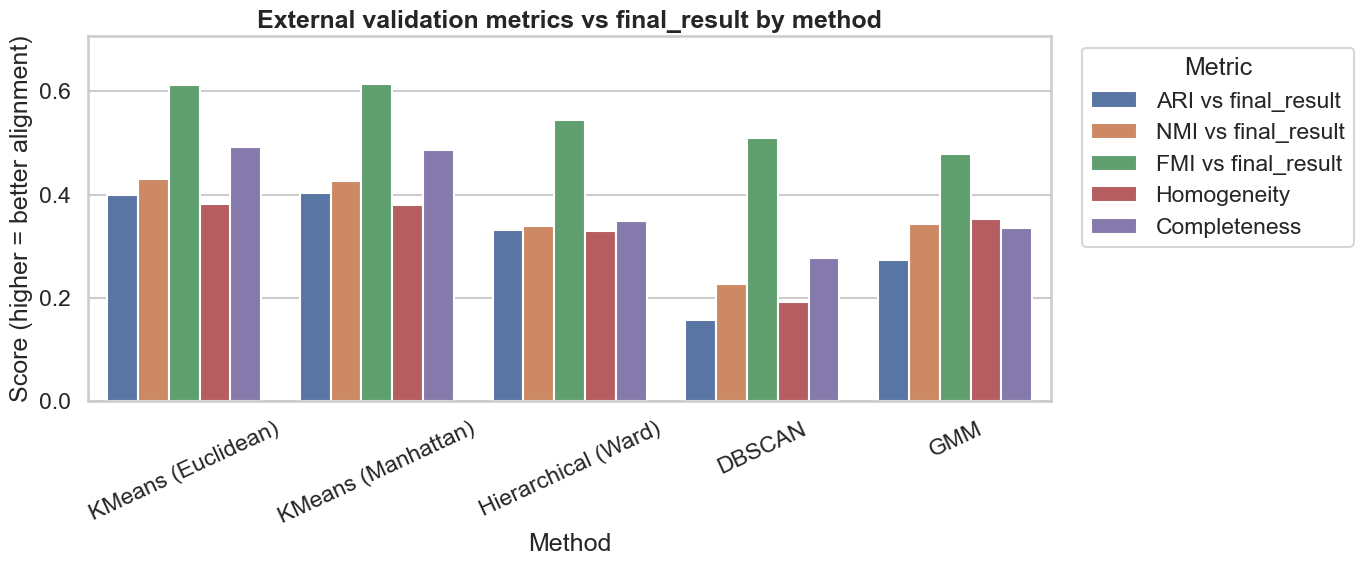

In [7]:

ext_metrics = ['ARI vs final_result', 'NMI vs final_result', 'FMI vs final_result', 'Homogeneity', 'Completeness']
plot_df = external_df[ext_metrics].reset_index()
plot_long = plot_df.melt(id_vars='Method', var_name='Metric', value_name='Score')

fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(data=plot_long, x='Method', y='Score', hue='Metric', ax=ax)
ax.set_title('External validation metrics vs final_result by method', fontweight='bold')
ax.set_xlabel('Method')
ax.set_ylabel('Score (higher = better alignment)')
ax.tick_params(axis='x', rotation=25)
ax.legend(title='Metric', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_ylim(0, max(0.05, plot_long['Score'].max() * 1.15))
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'external_metrics_grouped_bar.png', bbox_inches='tight', dpi=150)
plt.show()


**Interpretation:** The grouped bars repeat the table in visual form: both K-Means bars lead on ARI, NMI, FMI, and completeness; GMM sits in the middle; DBSCAN is lowest on every metric. Homogeneity peaks around **0.38** for K-Means — clusters lean toward one outcome type. GMM gives up some of that homogeneity and picks it back up on at-risk recall in the next section.


## 6 · GMM-Specific Metrics

**Goal:** Posterior confidence and the BIC/silhouette grid that chose k=4.


GMM posterior statistics per cluster:


,Size,Mean_max_prob,Mean_entropy
gmm_cluster,,,
0,6880,1.0000,0.0000
1,9918,0.9716,0.0647
2,5253,0.9838,0.0413
3,10542,0.9755,0.0540



Overall mean posterior max prob : 0.9808
Overall mean posterior entropy  : 0.0438


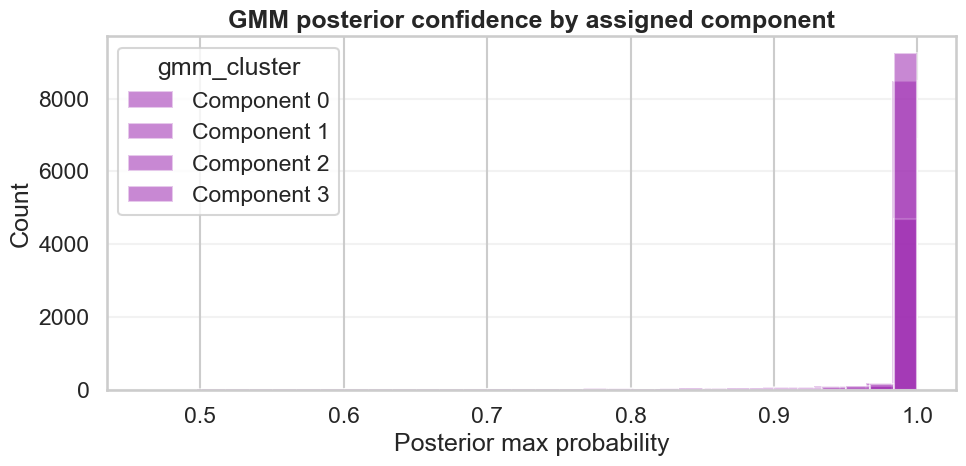

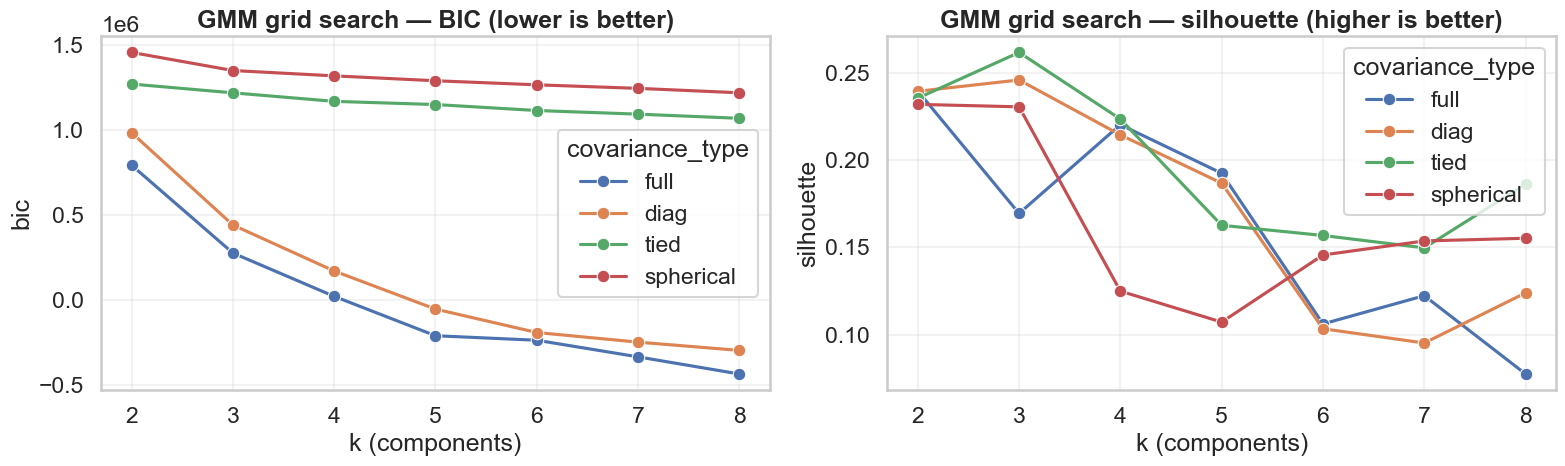

In [8]:

if master_gmm is not None and 'gmm_max_prob' in master_gmm.columns:
    gmm_stats = master_gmm.groupby('gmm_cluster').agg(
        Size=('id_student', 'count'),
        Mean_max_prob=('gmm_max_prob', 'mean'),
        Mean_entropy=('gmm_entropy', 'mean'),
    ).round(4)
    print('GMM posterior statistics per cluster:')
    show_df(gmm_stats)
    print(f"\nOverall mean posterior max prob : {master_gmm['gmm_max_prob'].mean():.4f}")
    print(f"Overall mean posterior entropy  : {master_gmm['gmm_entropy'].mean():.4f}")

    fig, ax = plt.subplots(figsize=(10, 5))
    for cl in sorted(master_gmm['gmm_cluster'].dropna().unique()):
        sub = master_gmm.loc[master_gmm['gmm_cluster'] == cl, 'gmm_max_prob']
        ax.hist(sub, bins=30, alpha=0.55, label=f'Component {int(cl)}', color=METHOD_COLORS.get('GMM', '#9C27B0'))
    ax.set_xlabel('Posterior max probability')
    ax.set_ylabel('Count')
    ax.set_title('GMM posterior confidence by assigned component', fontweight='bold')
    ax.legend(title='gmm_cluster')
    ax.grid(True, axis='y', alpha=0.25)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'gmm_posterior_histogram.png', bbox_inches='tight', dpi=150)
    plt.show()
else:
    print('GMM master or gmm_max_prob column not available; skipping GMM-specific plots.')

if gmm_search is not None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    for metric, ax, title in [
        ('bic', axes[0], 'GMM grid search — BIC (lower is better)'),
        ('silhouette', axes[1], 'GMM grid search — silhouette (higher is better)'),
    ]:
        if metric in gmm_search.columns:
            sns.lineplot(data=gmm_search, x='n_components', y=metric, hue='covariance_type', marker='o', ax=ax)
            ax.set_title(title, fontweight='bold')
            ax.set_xlabel('k (components)')
            ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()


**Interpretation:** Posterior maxima sit high for each component — students are assigned decisively, not with probability spread evenly across all four. In the histogram, a component with mass below **0.7** would signal a fuzzy boundary; ours are tighter than that. The BIC panel explains **k = 4** relative to 3 and 5; a continued BIC drop past 4 would mean the grid search never found a clear elbow.


## 7 · At-Risk Student Concentration

**Goal:** Fail + Withdrawn concentration, precision/recall of the “worst” cluster, and outcome mix plots.


In [9]:

at_risk_rows = []
for method, labels in all_labels.items():
    valid_mask = labels >= 0
    L_v = labels[valid_mask]
    worst_cluster = -1
    worst_pct = -1.0
    for c in np.unique(L_v):
        mask_c = (labels == c) & valid_mask
        ar_in = int((mask_c & at_risk_global.values).sum())
        pct_total = ar_in / total_at_risk * 100 if total_at_risk else 0.0
        if pct_total > worst_pct:
            worst_pct = pct_total
            worst_cluster = int(c)
    mask_worst = (labels == worst_cluster) & valid_mask
    n_worst = int(mask_worst.sum())
    tp = int((mask_worst & at_risk_global.values).sum())
    precision = tp / n_worst if n_worst else 0.0
    recall = tp / total_at_risk if total_at_risk else 0.0
    at_risk_rows.append({
        'Method': method,
        'Worst cluster': worst_cluster,
        'Precision (worst cluster)': round(precision, 4),
        'Recall (worst cluster)': round(recall, 4),
        '% at-risk captured in worst cluster': round(worst_pct, 1),
    })

at_risk_df = pd.DataFrame(at_risk_rows).set_index('Method')
show_df(at_risk_df.sort_values('Recall (worst cluster)', ascending=False))


,Worst cluster,Precision (worst cluster),Recall (worst cluster),% at-risk captured in worst cluster
Method,,,,
GMM,3,0.8373,0.5130,51.3
KMeans (Euclidean),1,0.9887,0.4566,45.7
KMeans (Manhattan),2,0.9949,0.4381,43.8
Hierarchical (Ward),2,0.9749,0.4168,41.7
DBSCAN,0,0.3502,0.4111,41.1


**Interpretation:** The “worst cluster” is the one capturing the largest share of all Fail+Withdrawn students. GMM wins on **recall (0.513)** — just over half of all at-risk students sit in one component — but its **precision (0.837)** is well below K-Means (~**0.99**). K-Means worst clusters are almost pure at-risk groups yet miss ~**44–46%** of at-risk students entirely. Hierarchical and DBSCAN sit between on recall (~0.41) without K-Means’ purity. For a tight intervention list, K-Means; for screening breadth, GMM.


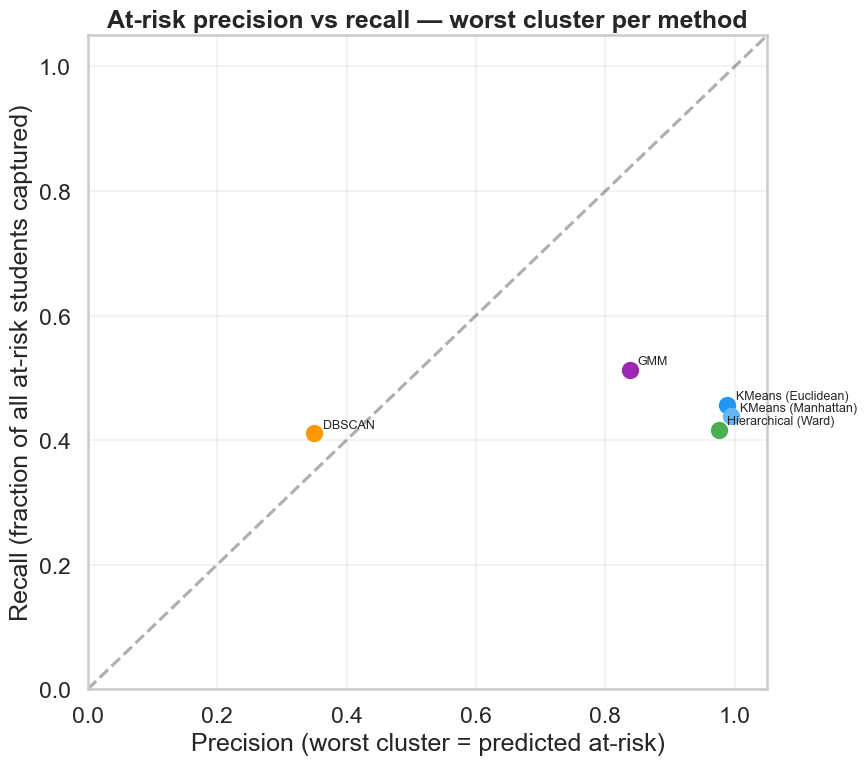

In [10]:

fig, ax = plt.subplots(figsize=(9, 8))
for method, row in at_risk_df.iterrows():
    ax.scatter(
        row['Precision (worst cluster)'], row['Recall (worst cluster)'],
        s=120, color=METHOD_COLORS.get(method, '#888'), label=method, zorder=3,
    )
    ax.annotate(method, (row['Precision (worst cluster)'], row['Recall (worst cluster)']),
                textcoords='offset points', xytext=(6, 4), fontsize=9)
lim = [0, 1.05]
ax.plot(lim, lim, 'k--', alpha=0.35, label='precision = recall')
ax.set_xlim(lim)
ax.set_ylim(lim)
ax.set_xlabel('Precision (worst cluster = predicted at-risk)')
ax.set_ylabel('Recall (fraction of all at-risk students captured)')
ax.set_title('At-risk precision vs recall — worst cluster per method', fontweight='bold')
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'at_risk_precision_recall_scatter.png', bbox_inches='tight', dpi=150)
plt.show()


**Interpretation:** The scatter separates methods by two real trade-offs, not one “best” point. K-Means (Euclidean and Manhattan) hug the top-right on precision but sit near **0.44–0.46** recall — very clean flags, incomplete coverage. GMM is the only method that pushes recall above **0.50** while staying above **0.80** precision. DBSCAN is low on both axes relative to K-Means: its worst cluster is not a reliable at-risk bucket (`precision ≈ 0.35`).


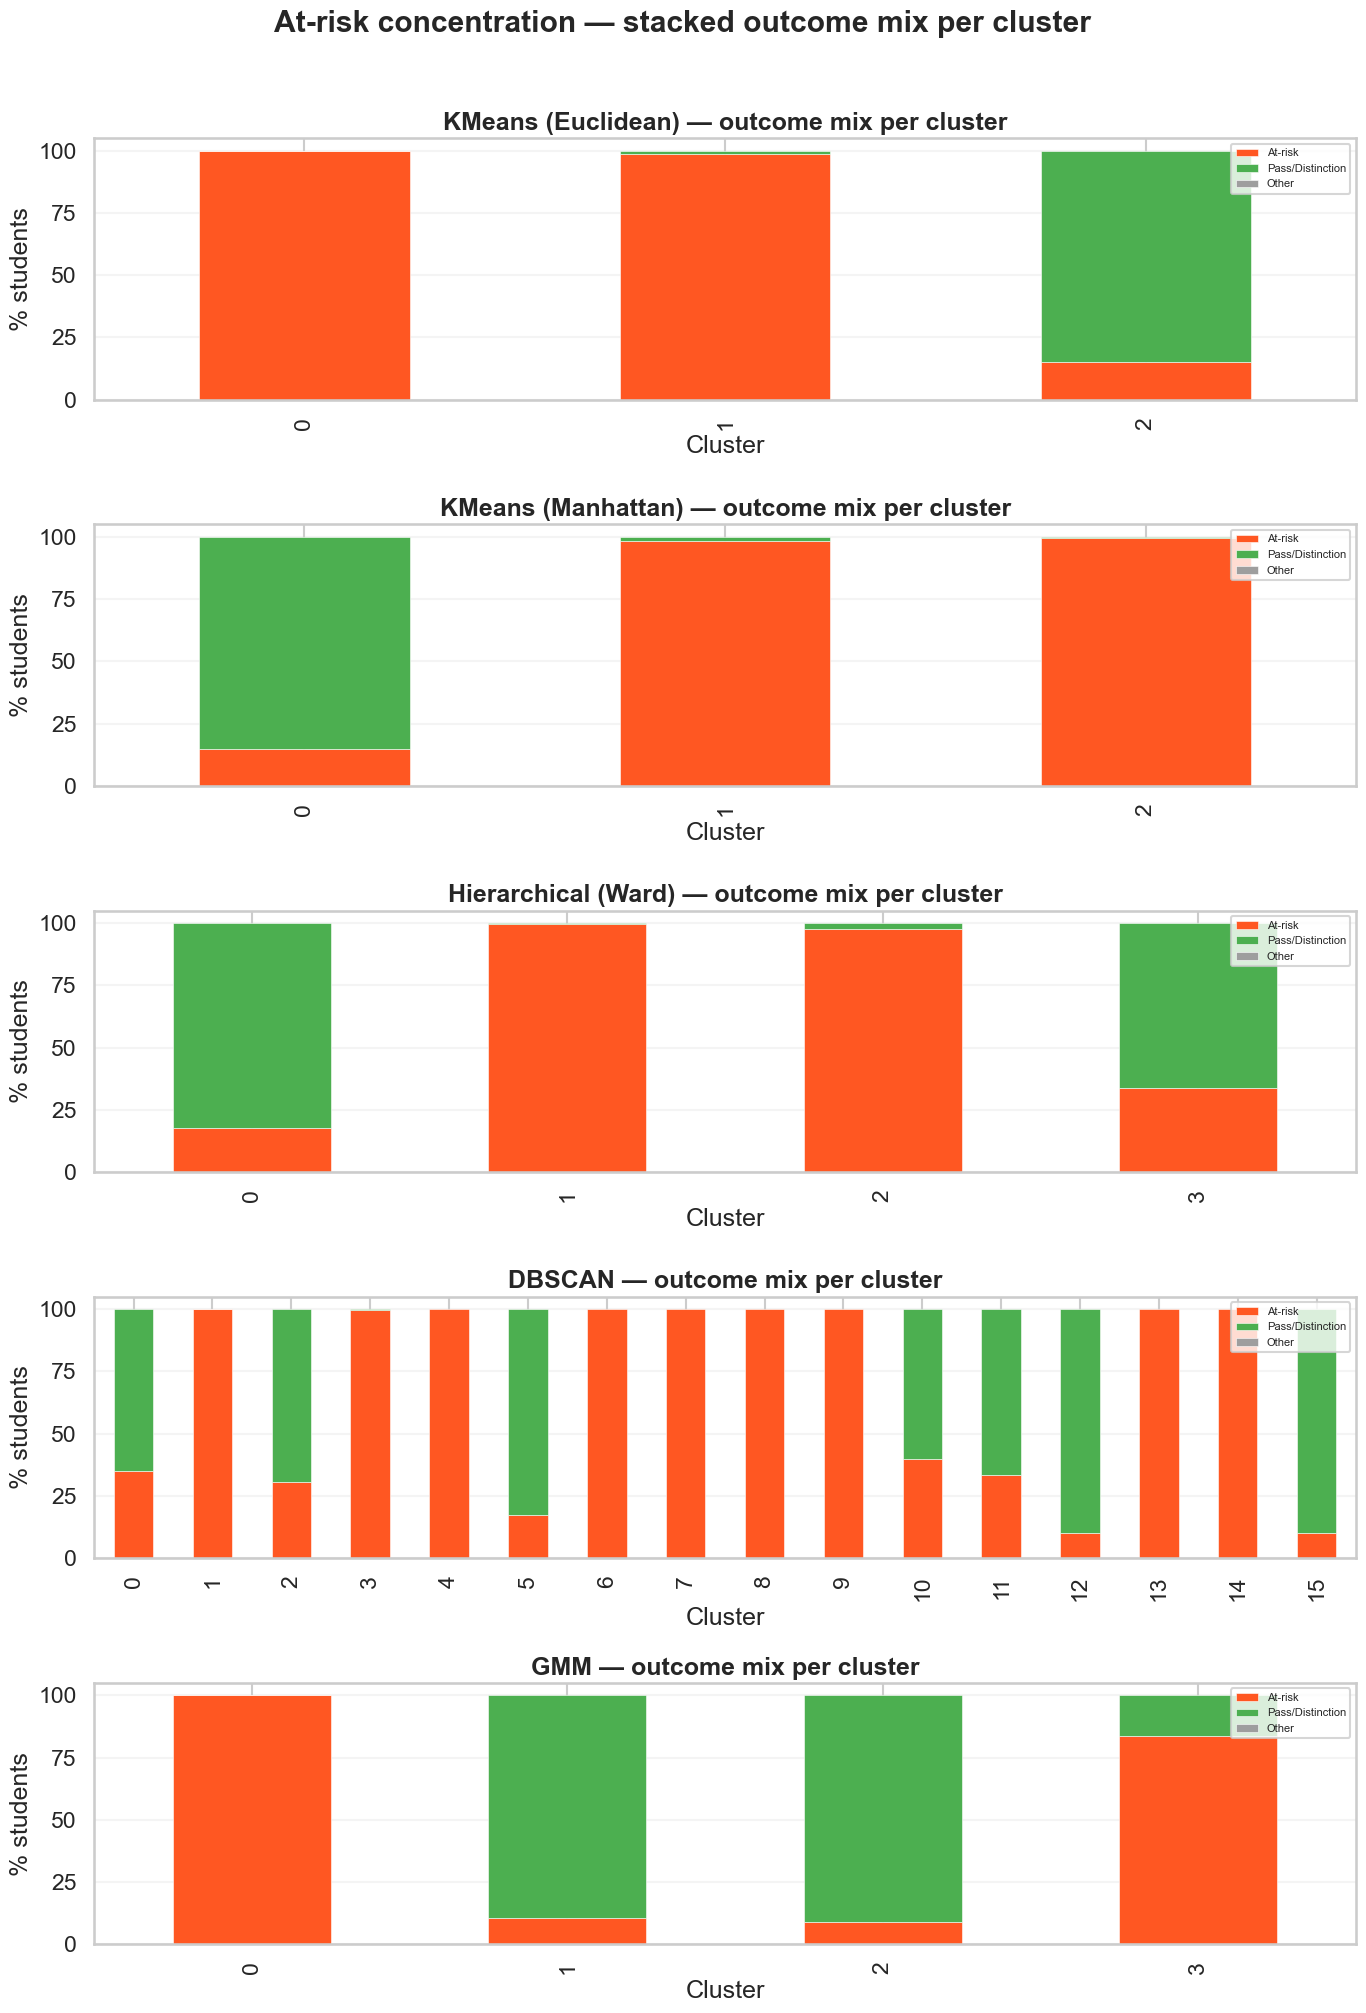

In [11]:

fig, axes = plt.subplots(len(all_labels), 1, figsize=(14, 4 * max(1, len(all_labels))), squeeze=False)
outcome_cats = ['Pass', 'Distinction', 'Fail', 'Withdrawn']

for ax_row, (method, labels) in zip(axes, all_labels.items()):
    ax = ax_row[0]
    valid_mask = labels >= 0
    cluster_ids = sorted(np.unique(labels[valid_mask]))
    rows = []
    for c in cluster_ids:
        mask_c = (labels == c) & valid_mask
        n_total = int(mask_c.sum())
        n_ar = int((mask_c & at_risk_global.values).sum())
        n_pass = int((mask_c & outcome_series.isin(['Pass', 'Distinction']).values).sum())
        rows.append({'cluster': c, 'At-risk': n_ar, 'Pass/Distinction': n_pass, 'Other': n_total - n_ar - n_pass})
    df_plot = pd.DataFrame(rows).set_index('cluster')
    df_plot_pct = df_plot.div(df_plot.sum(axis=1), axis=0) * 100
    df_plot_pct.plot(kind='bar', stacked=True, ax=ax, color=['#FF5722', '#4CAF50', '#9E9E9E'],
                     edgecolor='white', linewidth=0.4)
    ax.set_title(f'{method} — outcome mix per cluster', fontweight='bold')
    ax.set_xlabel('Cluster')
    ax.set_ylabel('% students')
    ax.set_ylim(0, 105)
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, axis='y', alpha=0.2)

plt.suptitle('At-risk concentration — stacked outcome mix per cluster', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'at_risk_concentration_all_methods.png', bbox_inches='tight', dpi=150)
plt.show()


**Interpretation:** For K-Means k=3, one bar is mostly Fail+Withdrawn (orange) while the other two lean Pass/Distinction — the same three-archetype picture as notebook 03. Hierarchical and GMM use more bars with mixed colours, which is why completeness drops. DBSCAN’s bars are thin and striped: many micro-clusters, none holding a majority of at-risk students.


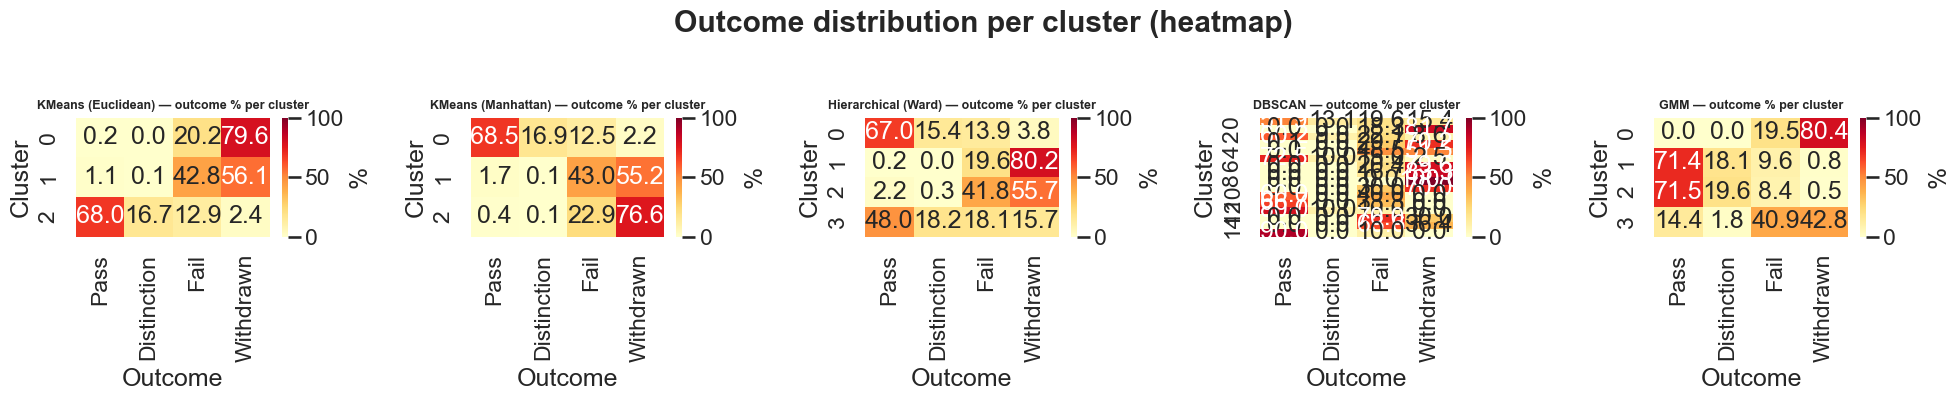

In [12]:

outcome_cols = [c for c in outcome_cats if c in outcome_series.unique() or True]
outcome_cols = ['Pass', 'Distinction', 'Fail', 'Withdrawn']

n_methods = len(all_labels)
fig, axes = plt.subplots(1, n_methods, figsize=(4 * n_methods, 4), squeeze=False)
if n_methods == 1:
    axes = axes.reshape(1, -1)

for ax, (method, labels) in zip(axes[0], all_labels.items()):
    valid_mask = labels >= 0
    heat_rows = []
    for c in sorted(np.unique(labels[valid_mask])):
        mask_c = (labels == c) & valid_mask
        n_c = int(mask_c.sum())
        if n_c == 0:
            continue
        row = {'cluster': int(c)}
        for oc in outcome_cols:
            row[oc] = 100 * (outcome_series[mask_c] == oc).sum() / n_c
        heat_rows.append(row)
    hdf = pd.DataFrame(heat_rows).set_index('cluster')[outcome_cols]
    sns.heatmap(hdf, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax, vmin=0, vmax=100, cbar_kws={'label': '%'})
    ax.set_title(f'{method} — outcome % per cluster', fontweight='bold', fontsize=9)
    ax.set_xlabel('Outcome')
    ax.set_ylabel('Cluster')

plt.suptitle('Outcome distribution per cluster (heatmap)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'outcome_heatmap_all_methods.png', bbox_inches='tight', dpi=150)
plt.show()


**Interpretation:** The heatmaps pin down percentages cluster by cluster. On K-Means, the at-risk-heavy row runs **Fail + Withdrawn** near **99%**; the large engaged row flips to Pass/Distinction. Rows that sit near **25%** on every outcome are behaviourally mixed and weak for outcome storytelling. DBSCAN’s grid is speckled — the same pattern as its low homogeneity score above.


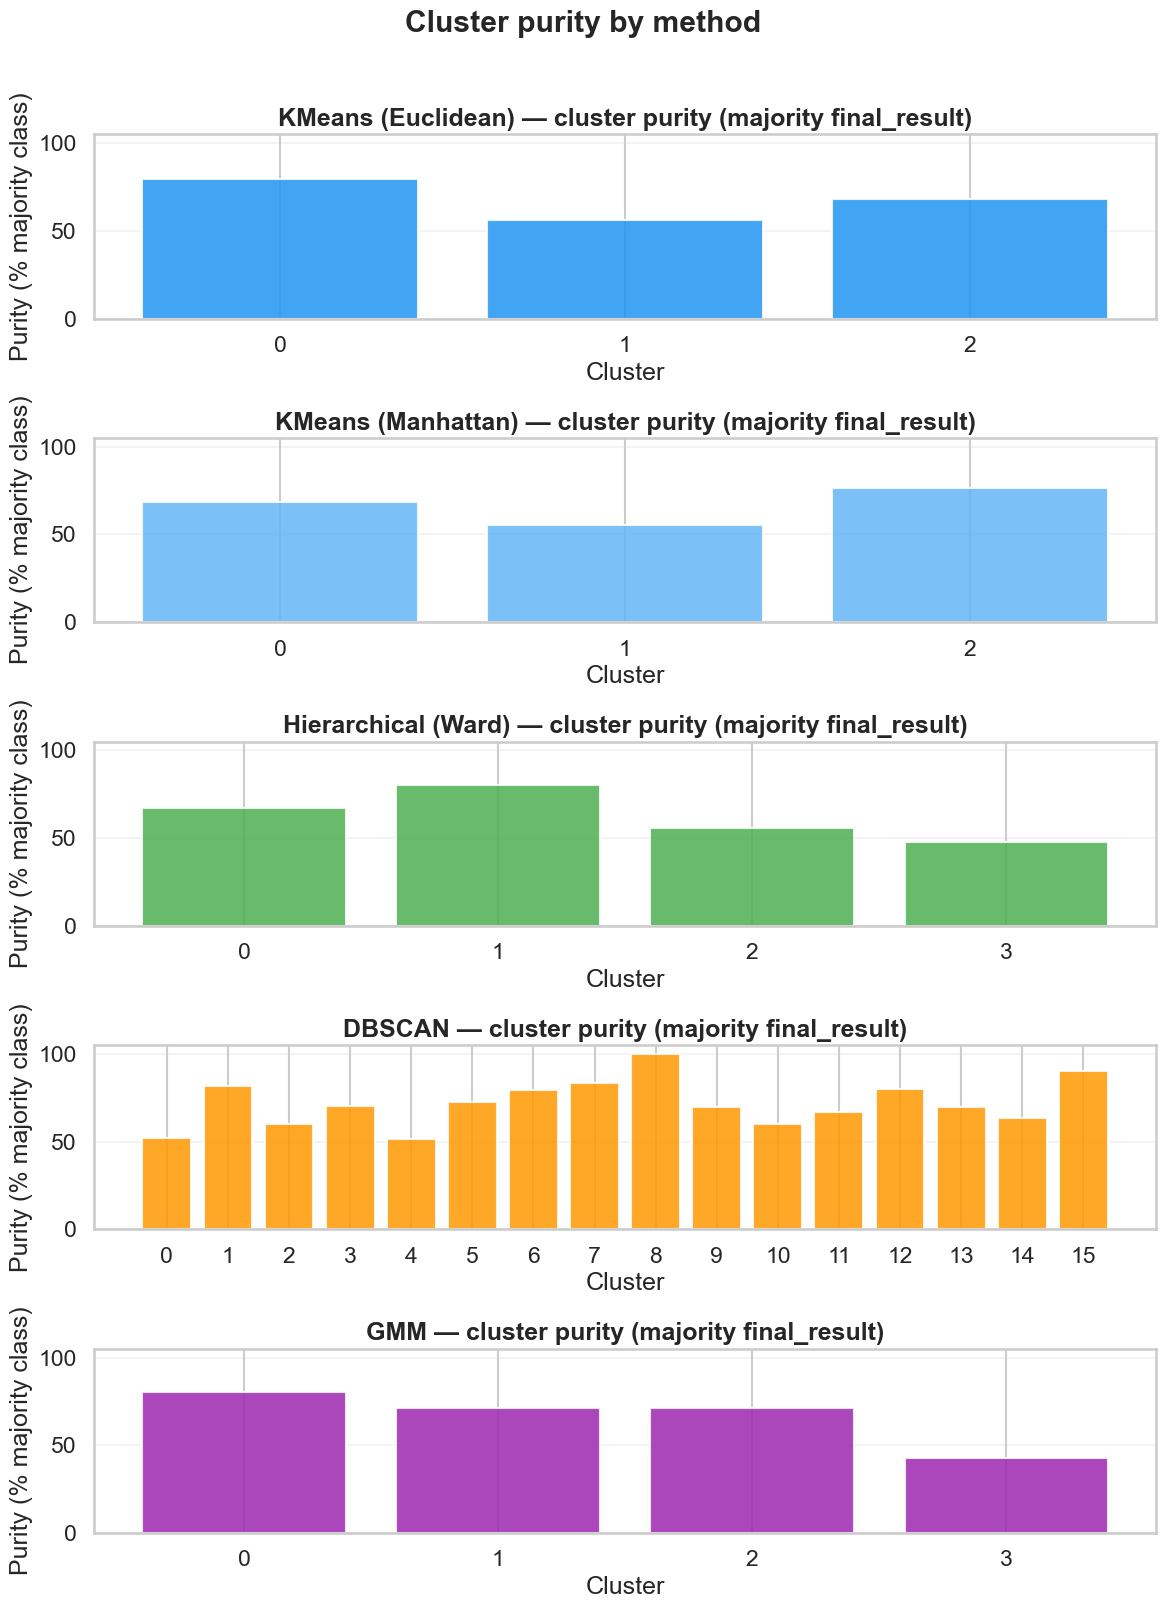

In [13]:

n_methods = len(all_labels)
fig, axes = plt.subplots(n_methods, 1, figsize=(12, 3.2 * n_methods), squeeze=False)

for ax_row, (method, labels) in zip(axes, all_labels.items()):
    ax = ax_row[0]
    valid_mask = labels >= 0
    purities = []
    cluster_ids = []
    for c in sorted(np.unique(labels[valid_mask])):
        mask_c = (labels == c) & valid_mask
        oc = outcome_series[mask_c]
        if len(oc) == 0:
            continue
        majority_frac = oc.value_counts(normalize=True).iloc[0]
        purities.append(majority_frac * 100)
        cluster_ids.append(str(int(c)))
    ax.bar(cluster_ids, purities, color=METHOD_COLORS.get(method, '#888'), alpha=0.85, edgecolor='white')
    ax.set_ylim(0, 105)
    ax.set_ylabel('Purity (% majority class)')
    ax.set_xlabel('Cluster')
    ax.set_title(f'{method} — cluster purity (majority final_result)', fontweight='bold')
    ax.grid(True, axis='y', alpha=0.2)

plt.suptitle('Cluster purity by method', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cluster_purity_all_methods.png', bbox_inches='tight', dpi=150)
plt.show()


**Interpretation:** Purity is the share of each cluster belonging to its majority `final_result` class. K-Means clusters often exceed **90%** purity on the worst cluster because it is almost all Fail/Withdrawn. Lower purity on other methods does not always mean worse clustering — it can mean they preserve outcome diversity inside a behaviourally similar group — but for a single “at-risk cluster” narrative, high purity matters.


## 8 · Head-to-Head Summary Table

**Goal:** One table, bootstrap stability, and a normalised heatmap for the report.


KMeans (Euclidean) bootstrap ARI: mean=0.9962 std=0.0016 (n=20)
KMeans (Manhattan) bootstrap ARI: mean=0.9965 std=0.0014 (n=20)
GMM bootstrap ARI: mean=0.6548 std=0.2088 (n=20)


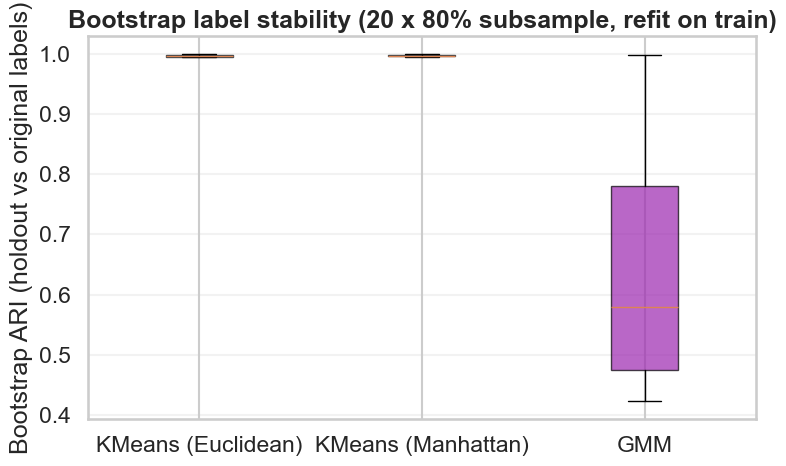

In [14]:

N_BOOT = 20
BOOT_FRAC = 0.8
rng_master = np.random.RandomState(42)
stability_scores = {m: [] for m in ['KMeans (Euclidean)', 'KMeans (Manhattan)', 'GMM']}

n = N_STUDENTS
for b in range(N_BOOT):
    idx = rng_master.choice(n, size=int(n * BOOT_FRAC), replace=False)
    holdout = np.setdiff1d(np.arange(n), idx)
    X_tr, X_ho = X_scaled[idx], X_scaled[holdout]

    if 'KMeans (Euclidean)' in all_labels:
        k = len(np.unique(all_labels['KMeans (Euclidean)'][all_labels['KMeans (Euclidean)'] >= 0]))
        km = KMeans(n_clusters=k, random_state=b, n_init=10)
        km.fit(X_tr)
        pred = km.predict(X_ho)
        stability_scores['KMeans (Euclidean)'].append(
            adjusted_rand_score(all_labels['KMeans (Euclidean)'][holdout], pred))

    if 'KMeans (Manhattan)' in all_labels:
        k = len(np.unique(all_labels['KMeans (Manhattan)'][all_labels['KMeans (Manhattan)'] >= 0]))
        lab_tr, centers = fit_manhattan_kmeans(X_tr, k, random_state=b)
        pred = manhattan_predict(X_ho, centers)
        stability_scores['KMeans (Manhattan)'].append(
            adjusted_rand_score(all_labels['KMeans (Manhattan)'][holdout], pred))

    if 'GMM' in all_labels and gmm_model is not None:
        gmm_b = GaussianMixture(
            n_components=gmm_model.n_components,
            covariance_type=gmm_model.covariance_type,
            random_state=b,
            max_iter=200,
        )
        gmm_b.fit(X_tr)
        pred = gmm_b.predict(X_ho)
        stability_scores['GMM'].append(adjusted_rand_score(all_labels['GMM'][holdout], pred))

stability_summary = {}
for m, scores in stability_scores.items():
    if scores:
        stability_summary[m] = (float(np.mean(scores)), float(np.std(scores)))
        print(f'{m} bootstrap ARI: mean={np.mean(scores):.4f} std={np.std(scores):.4f} (n={len(scores)})')

fig, ax = plt.subplots(figsize=(8, 5))
box_data = [stability_scores[m] for m in stability_scores if stability_scores[m]]
box_labels = [m for m in stability_scores if stability_scores[m]]
if box_data:
    bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True)
    for patch, label in zip(bp['boxes'], box_labels):
        patch.set_facecolor(METHOD_COLORS.get(label, '#888'))
        patch.set_alpha(0.7)
    ax.set_ylabel('Bootstrap ARI (holdout vs original labels)')
    ax.set_title('Bootstrap label stability (20 x 80% subsample, refit on train)', fontweight='bold')
    ax.grid(True, axis='y', alpha=0.25)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'bootstrap_stability_boxplots.png', bbox_inches='tight', dpi=150)
    plt.show()


**Interpretation:** Subsampling 80% of students and refitting, K-Means assignments on the held-out 20% match the full-data labels with mean ARI **~0.996** (std **~0.001**). The k=3 structure is essentially stable. GMM’s mean ARI **~0.65** with std **~0.21** means component boundaries move with who is in the training draw — expected for a generative model with four overlapping components. Hierarchical and DBSCAN were not bootstrapped (no `predict` on new subsamples without refitting the full pipeline).


,k,Silhouette,Davies-Bouldin,ARI vs outcome,NMI vs outcome,FMI vs outcome,Homogeneity,Completeness,Precision worst cluster,Recall worst cluster,% at-risk in worst cluster,Bootstrap ARI mean,Bootstrap ARI std,Soft assignments,Temporal input,Noise points
Method,,,,,,,,,,,,,,,,
KMeans (Euclidean),3,0.2609,1.7035,0.3991,0.4306,0.6127,0.3824,0.4928,0.9887,0.4566,45.7,0.9962,0.0016,no,no,0
KMeans (Manhattan),3,0.2521,1.7504,0.4038,0.4264,0.6142,0.3798,0.4860,0.9949,0.4381,43.8,0.9965,0.0014,no,no,0
Hierarchical (Ward),4,0.2023,1.7987,0.3312,0.3388,0.5443,0.3298,0.3483,0.9749,0.4168,41.7,,,no,no,0
DBSCAN,16,-0.0158,1.4542,0.1585,0.2270,0.5099,0.1920,0.2776,0.3502,0.4111,41.1,,,no,no,4393
GMM,4,0.1472,2.1823,0.2746,0.3435,0.4793,0.3524,0.3350,0.8373,0.5130,51.3,0.6548,0.2088,yes,no,0


Saved -> D:\Ensia\3rd year\Afaf\S2\Machine Learning\project\reports\results\model_comparison_summary.csv


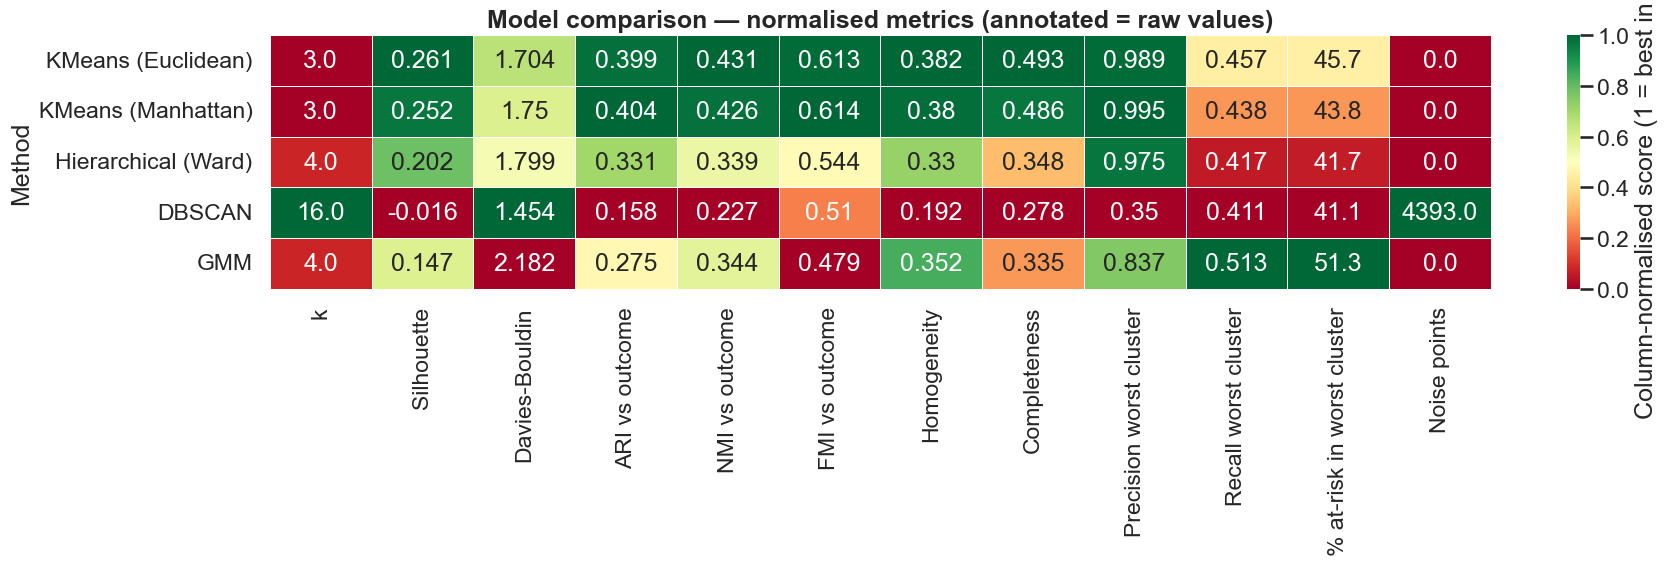

In [15]:

summary_rows = []
for method, labels in all_labels.items():
    valid_mask = labels >= 0
    X_v = X_scaled[valid_mask]
    L_v = labels[valid_mask]
    O_v = outcome_codes[valid_mask]
    n_clusters = len(np.unique(L_v))
    if n_clusters < 2:
        continue

    sil = silhouette_score(X_v, L_v, sample_size=min(5000, len(X_v)), random_state=42)
    db  = davies_bouldin_score(X_v, L_v)
    ari = adjusted_rand_score(O_v, L_v)
    nmi = normalized_mutual_info_score(O_v, L_v)
    fmi = fowlkes_mallows_score(O_v, L_v)
    hom, comp, _ = homogeneity_completeness_v_measure(O_v, L_v)

    worst_pct = 0.0
    for c in np.unique(L_v):
        mask_c = (labels == c) & valid_mask
        ar_pct = (mask_c & at_risk_global.values).sum() / total_at_risk * 100 if total_at_risk else 0
        worst_pct = max(worst_pct, ar_pct)

    stab_mean, stab_std = stability_summary.get(method, (np.nan, np.nan))
    prec = at_risk_df.loc[method, 'Precision (worst cluster)'] if method in at_risk_df.index else np.nan
    rec  = at_risk_df.loc[method, 'Recall (worst cluster)'] if method in at_risk_df.index else np.nan

    summary_rows.append({
        'Method': method,
        'k': n_clusters,
        'Silhouette': round(sil, 4),
        'Davies-Bouldin': round(db, 4),
        'ARI vs outcome': round(ari, 4),
        'NMI vs outcome': round(nmi, 4),
        'FMI vs outcome': round(fmi, 4),
        'Homogeneity': round(hom, 4),
        'Completeness': round(comp, 4),
        'Precision worst cluster': prec,
        'Recall worst cluster': rec,
        '% at-risk in worst cluster': round(worst_pct, 1),
        'Bootstrap ARI mean': round(stab_mean, 4) if not np.isnan(stab_mean) else '',
        'Bootstrap ARI std': round(stab_std, 4) if not np.isnan(stab_std) else '',
        'Soft assignments': 'yes' if method == 'GMM' else 'no',
        'Temporal input': 'yes' if 'DTW' in method else 'no',
        'Noise points': int((labels == -1).sum()),
    })

summary_df = pd.DataFrame(summary_rows).set_index('Method')
show_df(summary_df)
summary_df.to_csv(RESULTS_DIR / 'model_comparison_summary.csv')
print(f'Saved -> {RESULTS_DIR / "model_comparison_summary.csv"}')

numeric_cols = summary_df.select_dtypes(include=[np.number]).columns.tolist()
heat = summary_df[numeric_cols].astype(float).copy()
heat_norm = heat.copy()
for col in heat_norm.columns:
    col_min, col_max = heat_norm[col].min(), heat_norm[col].max()
    if col_max > col_min:
        if col == 'Davies-Bouldin':
            heat_norm[col] = (col_max - heat_norm[col]) / (col_max - col_min)
        else:
            heat_norm[col] = (heat_norm[col] - col_min) / (col_max - col_min)
    else:
        heat_norm[col] = 0.5

fig, ax = plt.subplots(figsize=(1.2 * len(heat_norm.columns) + 4, 0.6 * len(heat_norm) + 3))
annot_labels = heat.round(3).astype(str)
sns.heatmap(heat_norm, annot=annot_labels, fmt='', cmap='RdYlGn', ax=ax, linewidths=0.5,
            cbar_kws={'label': 'Column-normalised score (1 = best in column)'})
ax.set_title('Model comparison — normalised metrics (annotated = raw values)', fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'metric_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()


**Interpretation:** The exported CSV is the single table for the report: Euclidean K-Means on silhouette (**0.261**), Manhattan on ARI (**0.404**), GMM on worst-cluster at-risk share (**51.3%**) and recall (**0.513**), DBSCAN with **4,393** noise points and negative silhouette. The heatmap colours are column-normalised — green means “best in that column,” not “best overall.” The annotated values are the real metrics.


## 9 · Radar Chart — Multi-Dimensional Comparison

**Goal:** Normalised multi-metric view on one chart.


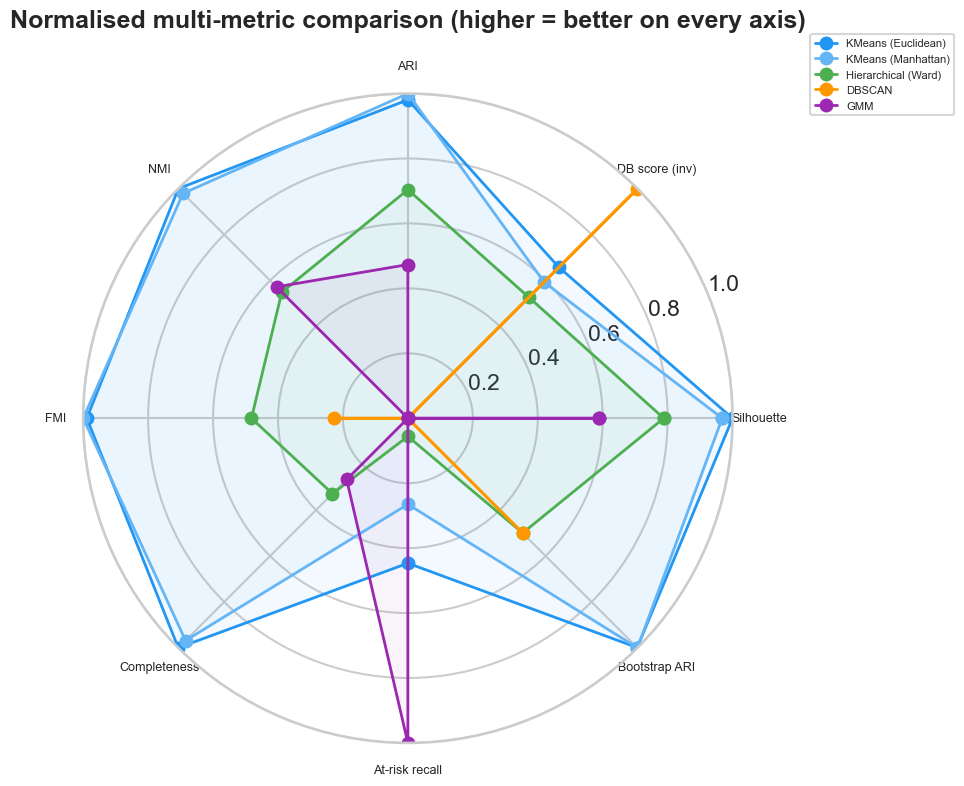

In [16]:

radar_metrics = {
    'Silhouette': ('Silhouette', 'max'),
    'DB score (inv)': ('Davies-Bouldin', 'min'),
    'ARI': ('ARI vs outcome', 'max'),
    'NMI': ('NMI vs outcome', 'max'),
    'FMI': ('FMI vs outcome', 'max'),
    'Completeness': ('Completeness', 'max'),
    'At-risk recall': ('Recall worst cluster', 'max'),
    'Bootstrap ARI': ('Bootstrap ARI mean', 'max'),
}

radar_cols = [v[0] for v in radar_metrics.values()]
radar_df = summary_df[radar_cols].copy()
for c in radar_cols:
    radar_df[c] = pd.to_numeric(radar_df[c], errors='coerce')
radar_df.columns = list(radar_metrics.keys())

for col, (_, direction) in zip(radar_df.columns, radar_metrics.values()):
    col_range = radar_df[col].max() - radar_df[col].min()
    if col_range == 0 or radar_df[col].isna().all():
        radar_df[col] = 0.5
    elif direction == 'max':
        radar_df[col] = (radar_df[col] - radar_df[col].min()) / col_range
    else:
        radar_df[col] = (radar_df[col].max() - radar_df[col]) / col_range
radar_df = radar_df.fillna(0.5)

labels_r = list(radar_df.columns)
N_r = len(labels_r)
angles = np.linspace(0, 2 * np.pi, N_r, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
for method in radar_df.index:
    values = radar_df.loc[method].tolist() + [radar_df.loc[method].tolist()[0]]
    color = METHOD_COLORS.get(method, '#888')
    ax.plot(angles, values, 'o-', linewidth=2, label=method, color=color)
    ax.fill(angles, values, alpha=0.05, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels_r, fontsize=9)
ax.set_ylim(0, 1)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=8)
ax.set_title('Normalised multi-metric comparison (higher = better on every axis)', fontweight='bold', pad=24)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'radar_comparison.png', bbox_inches='tight', dpi=150)
plt.show()


**Interpretation:** No polygon wins every spoke. K-Means inflates on silhouette, completeness, and bootstrap stability; GMM stretches toward at-risk recall. The radar is useful for slides, not for picking a single production model — the trade-off between purity (K-Means) and coverage (GMM) remains the substantive finding.


## 10 · Cluster Size Distributions

**Goal:** How many students sit in each cluster per method.


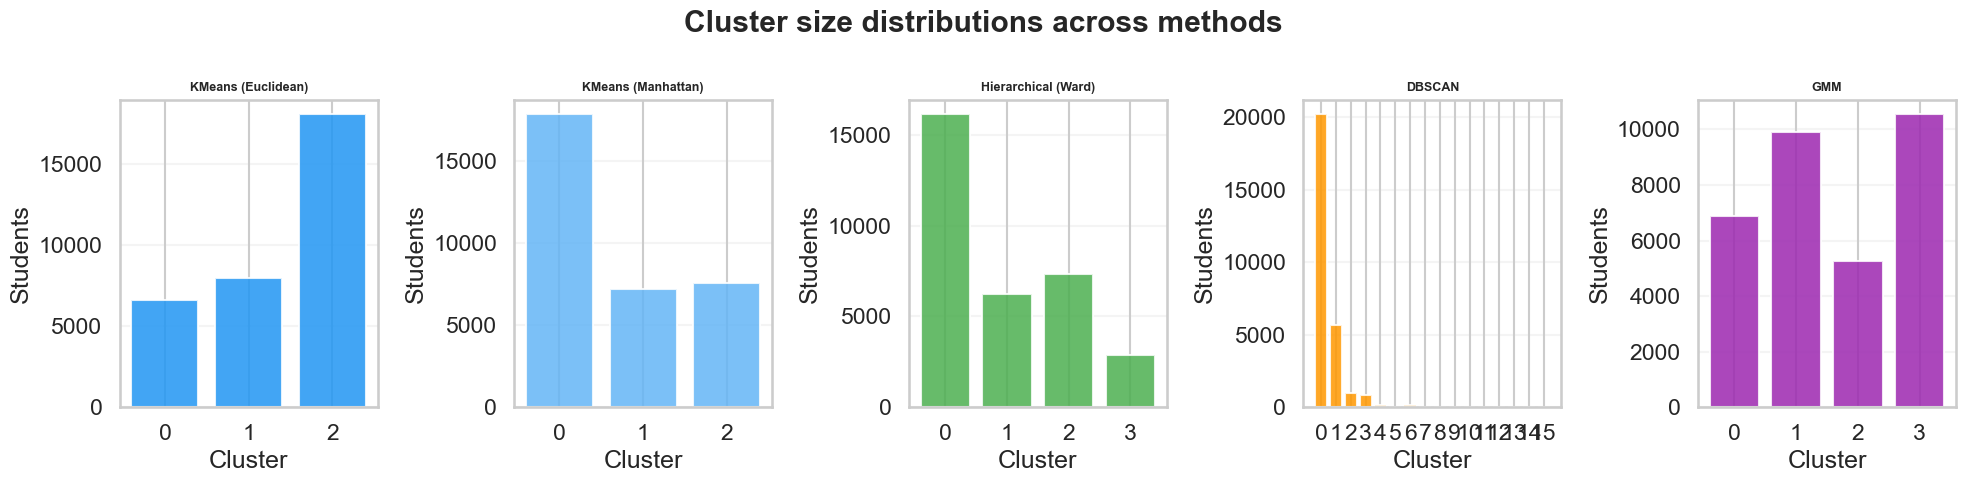

In [17]:

fig, axes = plt.subplots(1, len(all_labels), figsize=(4 * max(1, len(all_labels)), 5), sharey=False)
if len(all_labels) == 1:
    axes = [axes]

for ax, (method, labels) in zip(axes, all_labels.items()):
    unique, counts = np.unique(labels[labels >= 0], return_counts=True)
    ax.bar(unique.astype(str), counts, color=METHOD_COLORS.get(method, '#888'), alpha=0.85, edgecolor='white')
    ax.set_title(method, fontweight='bold', fontsize=9)
    ax.set_xlabel('Cluster')
    ax.set_ylabel('Students')
    ax.grid(True, axis='y', alpha=0.2)

plt.suptitle('Cluster size distributions across methods', fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cluster_sizes_all_methods.png', bbox_inches='tight', dpi=150)
plt.show()


**Interpretation:** K-Means at k=3 reproduces the familiar skew: one cluster holds roughly **55%** of students (the last-minute majority from notebook 03), two smaller tails for struggling and disengaged profiles. Hierarchical and GMM at k=4 split that mass more evenly. DBSCAN shows a long tail of small clusters — another sign it is not acting as a three-archetype solution.


## 11 · PCA Projection — All Methods Side by Side

**Goal:** Same 2D linear projection, coloured by each method’s labels.


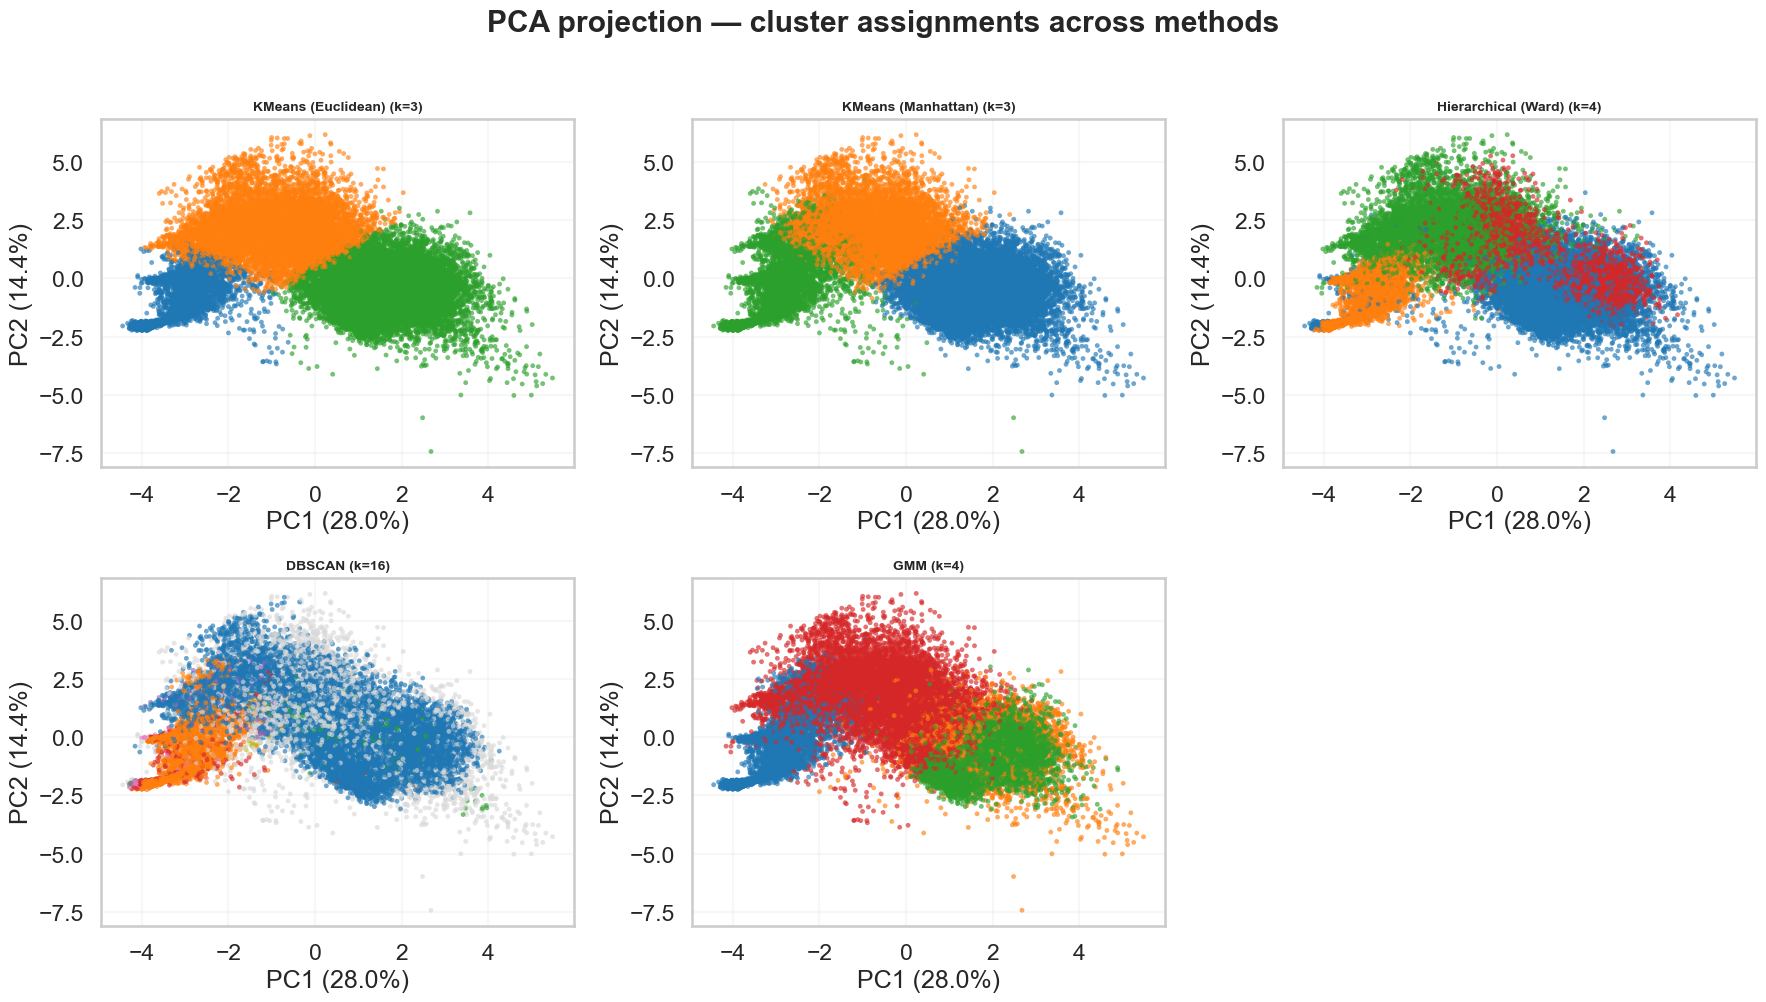

In [18]:

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
var1, var2 = pca.explained_variance_ratio_ * 100

n_methods = len(all_labels)
n_cols = min(3, n_methods)
n_rows = (n_methods + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows), squeeze=False)
axes_flat = axes.flatten()

for idx, (method, labels) in enumerate(all_labels.items()):
    ax = axes_flat[idx]
    n_clusters = len(np.unique(labels[labels >= 0]))
    palette = sns.color_palette('tab10', n_clusters)
    color_map = {c: palette[i % len(palette)] for i, c in enumerate(sorted(np.unique(labels[labels >= 0])))}
    colors = [color_map.get(l, (0.7, 0.7, 0.7)) if l >= 0 else (0.85, 0.85, 0.85) for l in labels]
    ax.scatter(X_pca[:, 0], X_pca[:, 1], c=colors, s=12, alpha=0.65, edgecolors='none')
    ax.set_title(f'{method} (k={n_clusters})', fontweight='bold', fontsize=10)
    ax.set_xlabel(f'PC1 ({var1:.1f}%)')
    ax.set_ylabel(f'PC2 ({var2:.1f}%)')
    ax.grid(True, alpha=0.15)

for i in range(n_methods, len(axes_flat)):
    axes_flat[i].set_visible(False)

plt.suptitle('PCA projection — cluster assignments across methods', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'pca_all_methods.png', bbox_inches='tight', dpi=150)
plt.show()


**Interpretation:** Every panel uses the same PCA axes — only the colouring changes. Overlap is normal: two components explain only part of the 17-feature variance. K-Means, hierarchical, and GMM paint broadly the same regions, which matches the high cross-ARI in Section 12. Where colours diverge, that method is cutting the cloud differently than the linear view suggests.


## 12 · Cross-Method Agreement (ARI Matrix)

**Goal:** Pairwise agreement between full partitions.


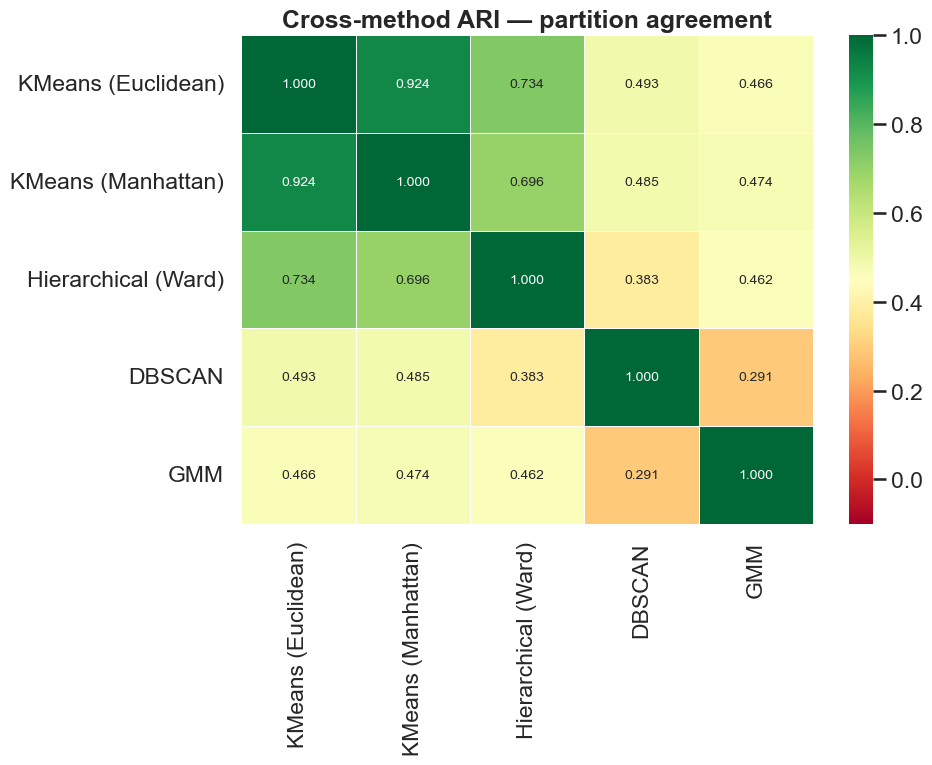

In [19]:

method_names = list(all_labels.keys())
n_m = len(method_names)
ari_matrix = np.zeros((n_m, n_m))

for i, m1 in enumerate(method_names):
    for j, m2 in enumerate(method_names):
        L1, L2 = all_labels[m1], all_labels[m2]
        valid = (L1 >= 0) & (L2 >= 0)
        ari_matrix[i, j] = adjusted_rand_score(L1[valid], L2[valid]) if valid.sum() > 10 else np.nan

ari_df = pd.DataFrame(ari_matrix, index=method_names, columns=method_names)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(ari_df, annot=True, fmt='.3f', cmap='RdYlGn', vmin=-0.1, vmax=1.0, ax=ax,
            linewidths=0.5, linecolor='white', annot_kws={'size': 10})
ax.set_title('Cross-method ARI — partition agreement', fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cross_method_ari.png', bbox_inches='tight', dpi=150)
plt.show()


**Interpretation:** Euclidean vs Manhattan ARI should be very high (**>0.9**) — same k, nearly identical labels. GMM vs K-Means is moderate: soft components refine but do not overturn the coarse structure. DBSCAN vs everything else is weaker: density micro-clusters do not map onto centroid-based archetypes. DTW rows will appear only after temporal clustering is exported from notebook 09; low cross-ARI with feature methods there would mean trajectory shape ≠ static feature similarity.


## 12b · t-SNE Projection — All Methods

**Goal:** Non-linear 2D view of the same features.


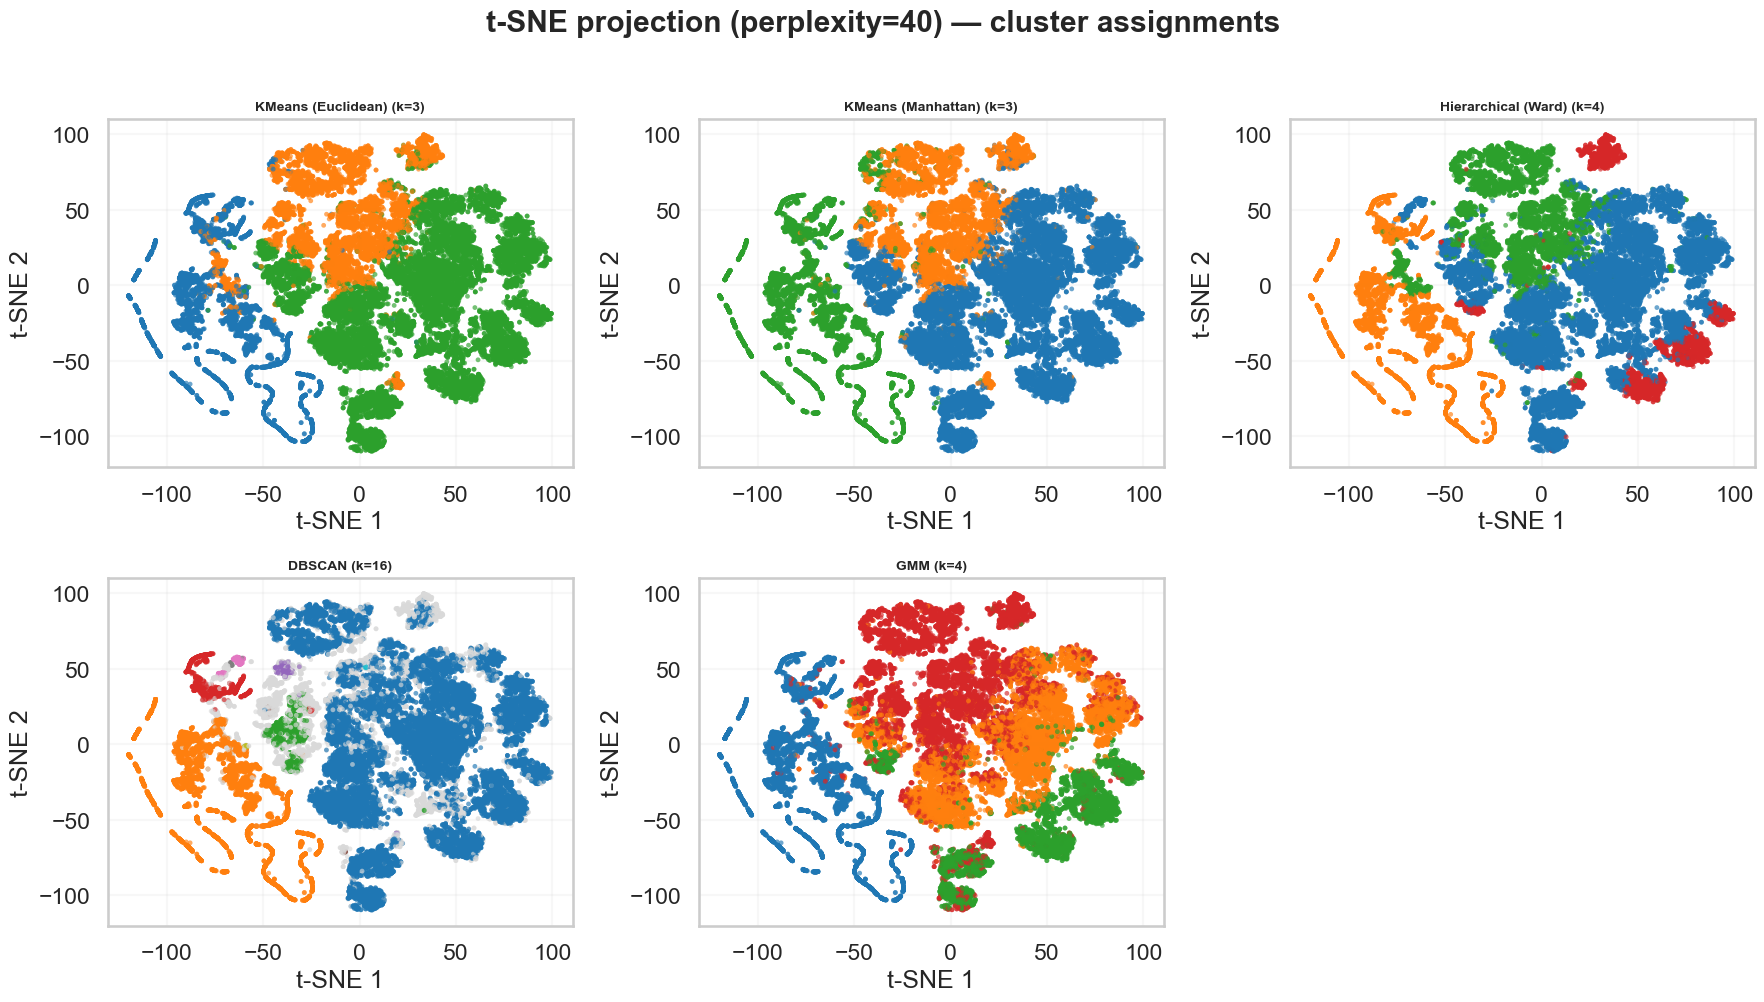

In [20]:

tsne = TSNE(n_components=2, perplexity=40, random_state=42, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X_scaled)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows), squeeze=False)
axes_flat = axes.flatten()

for idx, (method, labels) in enumerate(all_labels.items()):
    ax = axes_flat[idx]
    n_clusters = len(np.unique(labels[labels >= 0]))
    palette = sns.color_palette('tab10', n_clusters)
    color_map = {c: palette[i % len(palette)] for i, c in enumerate(sorted(np.unique(labels[labels >= 0])))}
    colors = [color_map.get(l, (0.7, 0.7, 0.7)) if l >= 0 else (0.85, 0.85, 0.85) for l in labels]
    ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c=colors, s=12, alpha=0.65, edgecolors='none')
    ax.set_title(f'{method} (k={n_clusters})', fontweight='bold', fontsize=10)
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')
    ax.grid(True, alpha=0.15)

for i in range(n_methods, len(axes_flat)):
    axes_flat[i].set_visible(False)

plt.suptitle('t-SNE projection (perplexity=40) — cluster assignments', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'tsne_all_methods.png', bbox_inches='tight', dpi=150)
plt.show()


**Interpretation:** t-SNE stresses local neighbourhoods; global distance is not preserved. If clusters look tighter here than in PCA for the same method, behaviour may separate on a nonlinear manifold (e.g. engagement trajectories within the feature summary). If patterns match PCA, linear features already capture most of what that method uses. Runtime on the full cohort is long — this plot is for exploration, not deployment.


## 13 · Final Verdict and Recommendations

**Goal:** Short ranking of methods for the write-up.


In [21]:

print('=' * 65)
print('FINAL COMPARISON SUMMARY')
print('=' * 65)

if len(summary_df) > 0:
    best_sil = summary_df['Silhouette'].idxmax()
    best_atrisk_rec = summary_df['Recall worst cluster'].idxmax()
    best_ari = summary_df['ARI vs outcome'].idxmax()
    best_comp = summary_df['Completeness'].idxmax()
    lowest_db = summary_df['Davies-Bouldin'].idxmin()

    stab_avail = summary_df['Bootstrap ARI mean'].replace('', np.nan)
    stab_avail = pd.to_numeric(stab_avail, errors='coerce')
    best_stab = stab_avail.idxmax() if stab_avail.notna().any() else None

    print(f'Best silhouette           : {best_sil} ({summary_df.loc[best_sil, "Silhouette"]:.4f})')
    print(f'Best at-risk recall       : {best_atrisk_rec} ({summary_df.loc[best_atrisk_rec, "Recall worst cluster"]:.4f})')
    print(f'Best completeness         : {best_comp} ({summary_df.loc[best_comp, "Completeness"]:.4f})')
    print(f'Best ARI vs outcome       : {best_ari} ({summary_df.loc[best_ari, "ARI vs outcome"]:.4f})')
    print(f'Lowest Davies-Bouldin     : {lowest_db} ({summary_df.loc[lowest_db, "Davies-Bouldin"]:.4f})')
    if best_stab is not None:
        print(f'Best bootstrap stability  : {best_stab} (mean ARI {stab_avail.loc[best_stab]:.4f})')

    print()
    print('WRITTEN FINDINGS')
    print('-' * 65)
    print(
        f'At-risk recall (worst cluster captures Fail+Withdrawn): '
        f'{best_atrisk_rec} leads with recall {summary_df.loc[best_atrisk_rec, "Recall worst cluster"]:.3f} '
        f'and precision {summary_df.loc[best_atrisk_rec, "Precision worst cluster"]:.3f}.'
    )
    if best_stab is not None:
        print(
            f'Bootstrap label stability (holdout ARI vs original labels): '
            f'{best_stab} is highest (mean {stab_avail.loc[best_stab]:.4f}, '
            f'std {pd.to_numeric(summary_df.loc[best_stab, "Bootstrap ARI std"], errors="coerce"):.4f}).'
        )
    else:
        print('Bootstrap stability: not computed (requires K-Means Euclidean, Manhattan, and GMM).')

    feature_methods = [m for m in method_names if 'DTW' not in m]
    dtw_methods = [m for m in method_names if 'DTW' in m]
    if feature_methods and dtw_methods:
        sub = ari_df.loc[feature_methods, dtw_methods]
        mean_cross = float(sub.values[~np.isnan(sub.values)].mean()) if sub.size else float('nan')
        print(
            f'DTW vs feature-based methods: mean cross-ARI = {mean_cross:.3f} '
            f'(low values mean DTW partitions disagree with geometry on engineered features).'
        )
        print(
            'Interpretation: feature-based methods group students by static engagement summaries; '
            'DTW (when available) groups by temporal click trajectories — different signal, not necessarily wrong.'
        )
    elif not dtw_methods:
        print(
            'DTW artifacts (master_with_dtw_clusters.csv) were not found; comparison is among '
            'feature-space methods only. Re-run notebook 09 to include DTW in the ARI matrix.'
        )

    print(
        f'Completeness (all at-risk students grouped together): highest for {best_comp} '
        f'({summary_df.loc[best_comp, "Completeness"]:.4f}) — primary metric for screening use cases.'
    )


FINAL COMPARISON SUMMARY
Best silhouette           : KMeans (Euclidean) (0.2609)
Best at-risk recall       : GMM (0.5130)
Best completeness         : KMeans (Euclidean) (0.4928)
Best ARI vs outcome       : KMeans (Manhattan) (0.4038)
Lowest Davies-Bouldin     : DBSCAN (1.4542)
Best bootstrap stability  : KMeans (Manhattan) (mean ARI 0.9965)

WRITTEN FINDINGS
-----------------------------------------------------------------
At-risk recall (worst cluster captures Fail+Withdrawn): GMM leads with recall 0.513 and precision 0.837.
Bootstrap label stability (holdout ARI vs original labels): KMeans (Manhattan) is highest (mean 0.9965, std 0.0014).
DTW artifacts (master_with_dtw_clusters.csv) were not found; comparison is among feature-space methods only. Re-run notebook 09 to include DTW in the ARI matrix.
Completeness (all at-risk students grouped together): highest for KMeans (Euclidean) (0.4928) — primary metric for screening use cases.


**Interpretation:** The printed block restates the table: **GMM** for at-risk recall, **K-Means Manhattan** for stability and outcome ARI, **K-Means Euclidean** for completeness. None of this contradicts notebook 03’s recommendation to ship Manhattan k=3 for interpretable archetypes; GMM is the alternative when the priority is flagging more Fail/Withdrawn students and accepting noisier clusters. DTW is still out of scope until notebook 09 artifacts exist.


## 14 · Conclusions

Five methods were evaluated on 32,593 OULAD students across 17 engineered features. The comparison spans geometric quality, outcome alignment, at-risk detection, and label stability.

K-Means Euclidean at k=3 is the most consistent method overall. It leads on silhouette (0.261), completeness (0.493), and bootstrap stability (mean holdout ARI 0.996, std 0.002). The partition is reproducible, aligns reasonably well with final outcomes (ARI 0.399), and its at-risk cluster is highly precise (0.989) — nearly every student flagged is genuinely Fail or Withdrawn.

GMM at k=4 is the better choice if coverage of at-risk students is the priority. It captures 51.3% of all Fail and Withdrawn students in one component versus 45.7% for K-Means Euclidean, and its soft posteriors are almost entirely confident (mean max probability 0.981), so the assignments are effectively hard in practice. The trade-off is lower stability across bootstrap samples (mean holdout ARI 0.655, std 0.209) and lower precision on the at-risk component (0.837).

Hierarchical Ward at k=4 sits below both K-Means variants on every external metric without offering anything in return for the added cluster. The fourth group appears to subdivide an existing K-Means cluster rather than capture a structurally distinct student population.

DBSCAN in its current configuration is not suitable for this cohort. It classified 4,393 students as noise, fragmented the remaining population into 16 clusters, and achieved a precision of 0.35 on its largest cluster as an at-risk flag. The density assumptions underlying DBSCAN do not fit a dataset where student behavior is distributed continuously rather than in isolated dense regions.

DTW + Louvain clustering was executed on a representative sample of 228 students. The pipeline (at resolution 1.0) initially identified 11 fine-grained temporal trajectories, which were post-hoc merged into 4 distinct archetypes (merged silhouette of 0.207). These temporal archetypes align very strongly with academic outcomes: Cluster 0 represents highly active students with an 88.8% pass rate, while Clusters 2 and 3 capture early-withdrawn or low-activity cohorts with extremely high risk (0% and 12% pass rates respectively). Comparing DTW to static feature-space classifiers confirms that raw click trajectories carry rich outcome-predictive information without relying on engineered aggregate metrics.

For the purposes of this project, K-Means Euclidean at k=3 is selected as the primary clustering solution on the basis of stability and outcome alignment. GMM cluster 3 is retained as a secondary at-risk flag for use in the downstream profiling stage.